VICON DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display plots inline
%matplotlib inline


In [2]:
# Path to your VICON CSV file
# Load the CSV file
df_vicon = pd.read_csv("/home/cpsl/px4_ws/live2_26.894_updated_param_and_manual_log60/csv_out/vicon__x500_7__x500_7.csv")

# Show basic info
print("Data summary:")
df_vicon.info()

# Display first few rows
df_vicon.head()


Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9688 entries, 0 to 9687
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   t                        9688 non-null   float64
 1   t_rel                    9688 non-null   float64
 2   header.stamp             9688 non-null   float64
 3   header.frame_id          9688 non-null   object 
 4   header.stamp.sec         9688 non-null   int64  
 5   header.stamp.nanosec     9688 non-null   int64  
 6   child_frame_id           9688 non-null   object 
 7   transform.translation.x  9688 non-null   float64
 8   transform.translation.y  9688 non-null   float64
 9   transform.translation.z  9688 non-null   float64
 10  transform.rotation.x     9688 non-null   float64
 11  transform.rotation.y     9688 non-null   float64
 12  transform.rotation.z     9688 non-null   float64
 13  transform.rotation.w     9688 non-null   float64
dtypes: float64

,t,t_rel,header.stamp,header.frame_id,header.stamp.sec,header.stamp.nanosec,child_frame_id,transform.translation.x,transform.translation.y,transform.translation.z,transform.rotation.x,transform.rotation.y,transform.rotation.z,transform.rotation.w
0,1.762620e+09,0.000000,1.762620e+09,vicon/world,1762620320,750038990,vicon/x500_7/x500_7,0.225929,-0.000983,0.903110,-0.001674,-0.015760,0.688591,0.724976
1,1.762620e+09,0.009966,1.762620e+09,vicon/world,1762620320,759913641,vicon/x500_7/x500_7,0.226062,-0.001084,0.903013,-0.002000,-0.016256,0.688830,0.724738
2,1.762620e+09,0.020282,1.762620e+09,vicon/world,1762620320,770080744,vicon/x500_7/x500_7,0.226300,-0.001050,0.903046,-0.001787,-0.015696,0.688748,0.724829
3,1.762620e+09,0.029968,1.762620e+09,vicon/world,1762620320,780052089,vicon/x500_7/x500_7,0.226457,-0.001061,0.902916,-0.001737,-0.016247,0.688681,0.724881
4,1.762620e+09,0.040155,1.762620e+09,vicon/world,1762620320,790102279,vicon/x500_7/x500_7,0.226649,-0.001035,0.902968,-0.001851,-0.015558,0.688873,0.724713


In [3]:
# ---------------- 1) Positions: keep ENU and add NED ----------------
# ENU from Vicon
x_e = df_vicon["transform.translation.x"].to_numpy()  # East
y_e = df_vicon["transform.translation.y"].to_numpy()  # North
z_e = df_vicon["transform.translation.z"].to_numpy()  # Up

# Save ENU positions explicitly
df_vicon["pos_east_enu"]   = x_e
df_vicon["pos_north_enu"]  = y_e
df_vicon["pos_up_enu"]     = z_e

# Convert ENU -> NED (world flip)
x_n = y_e         # North
y_n = x_e         # East
z_n = -z_e        # Down

df_vicon["pos_north_ned"] = x_n
df_vicon["pos_east_ned"]  = y_n
df_vicon["pos_down_ned"]  = z_n

print("✅ Stored positions in both ENU and NED frames.")

✅ Stored positions in both ENU and NED frames.


In [4]:
# ---------------- 2) Quaternions -> rotation matrix (vectorized) ----------------
# Expecting Vicon quaternion as orientation of body (FLU) in world (ENU): [x,y,z,w]
qx = df_vicon["transform.rotation.x"].to_numpy()
qy = df_vicon["transform.rotation.y"].to_numpy()
qz = df_vicon["transform.rotation.z"].to_numpy()
qw = df_vicon["transform.rotation.w"].to_numpy()

# Normalize (robustness)
norm = np.sqrt(qx*qx + qy*qy + qz*qz + qw*qw)
norm[norm == 0] = 1.0
qx, qy, qz, qw = qx/norm, qy/norm, qz/norm, qw/norm

def quat_array_to_rotmat(qx, qy, qz, qw):
    """
    Vectorized quaternion -> rotation matrix (N,3,3).
    Returns R_enu: rotation mapping body(FLU) vectors to world(ENU) vectors.
    """
    x, y, z, w = qx, qy, qz, qw
    xx, yy, zz = x*x, y*y, z*z
    xy, xz, yz = x*y, x*z, y*z
    wx, wy, wz = w*x, w*y, w*z

    R = np.empty((x.shape[0], 3, 3), dtype=float)
    R[:,0,0] = 1 - 2*(yy+zz)
    R[:,0,1] = 2*(xy - wz)
    R[:,0,2] = 2*(xz + wy)

    R[:,1,0] = 2*(xy + wz)
    R[:,1,1] = 1 - 2*(xx+zz)
    R[:,1,2] = 2*(yz - wx)

    R[:,2,0] = 2*(xz - wy)
    R[:,2,1] = 2*(yz + wx)
    R[:,2,2] = 1 - 2*(xx+yy)
    return R

R_enu = quat_array_to_rotmat(qx, qy, qz, qw)  # (N,3,3), body FLU -> world ENU

In [5]:
# ---------------- 3) Euler angles in ENU (FLU body) ----------------
# ZYX Tait–Bryan (yaw Z, pitch Y, roll X) from rotation mapping body->world
pitch_enu = np.arcsin(np.clip(-R_enu[:,2,0], -1.0, 1.0))
roll_enu  = np.arctan2(R_enu[:,2,1], R_enu[:,2,2])
yaw_enu   = np.arctan2(R_enu[:,1,0], R_enu[:,0,0])

df_vicon["roll_enu_deg"]  = np.degrees(roll_enu)
df_vicon["pitch_enu_deg"] = np.degrees(pitch_enu)
df_vicon["yaw_enu_deg"]   = np.degrees(yaw_enu)


In [6]:
# ---------------- 4) Euler angles in NED (FRD body) ----------------
# Fixed world flip: ENU -> NED
Cw = np.array([[0, 1, 0],    # x_N = y_E, y_N = x_E, z_N = -z_E
               [1, 0, 0],
               [0, 0,-1]], dtype=float)
# Fixed body flip: FLU -> FRD (roll 180°)
Cb = np.array([[ 1, 0, 0],
               [ 0,-1, 0],
               [ 0, 0,-1]], dtype=float)

# R_ned maps body(FRD) -> world(NED)
# R_ned = Cw * (R_enu) * Cb^T
R_ned = np.einsum('ij,njk,kl->nil', Cw, R_enu, Cb.T)  # (N,3,3)

pitch_ned = np.arcsin(np.clip(-R_ned[:,2,0], -1.0, 1.0))
roll_ned  = np.arctan2(R_ned[:,2,1], R_ned[:,2,2])
yaw_ned   = np.arctan2(R_ned[:,1,0], R_ned[:,0,0])

df_vicon["roll_ned_deg"]  = np.degrees(roll_ned)
df_vicon["pitch_ned_deg"] = np.degrees(pitch_ned)
df_vicon["yaw_ned_deg"]   = np.degrees(yaw_ned)

print("✅ Computed Euler angles in both ENU(FLU) and NED(FRD).")
print(df_vicon[[
    "pos_east_enu","pos_north_enu","pos_up_enu",
    "pos_north_ned","pos_east_ned","pos_down_ned",
    "roll_enu_deg","pitch_enu_deg","yaw_enu_deg",
    "roll_ned_deg","pitch_ned_deg","yaw_ned_deg"
]].head())

✅ Computed Euler angles in both ENU(FLU) and NED(FRD).
   pos_east_enu  pos_north_enu  pos_up_enu  pos_north_ned  pos_east_ned  \
0      0.225929      -0.000983    0.903110      -0.000983      0.225929   
1      0.226062      -0.001084    0.903013      -0.001084      0.226062   
2      0.226300      -0.001050    0.903046      -0.001050      0.226300   
3      0.226457      -0.001061    0.902916      -0.001061      0.226457   
4      0.226649      -0.001035    0.902968      -0.001035      0.226649   

   pos_down_ned  roll_enu_deg  pitch_enu_deg  yaw_enu_deg  roll_ned_deg  \
0     -0.903110     -1.383132      -1.177271    87.065287     -1.383132   
1     -0.903013     -1.449711      -1.192200    87.104761     -1.449711   
2     -0.903046     -1.387673      -1.162790    87.089798     -1.387673   
3     -0.902916     -1.426886      -1.212529    87.081138     -1.426886   
4     -0.902968     -1.382286      -1.146024    87.109123     -1.382286   

   pitch_ned_deg  yaw_ned_deg  
0       1.1

[NED] First 10s means — North: -0.003 m, East: 0.203 m, Down: -0.901 m


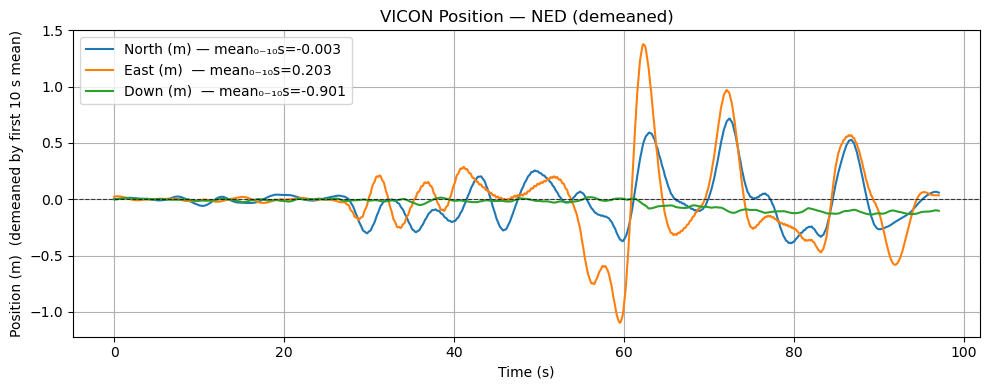

[ENU] First 10s means — East: 0.203 m, North: -0.003 m, Up: 0.901 m


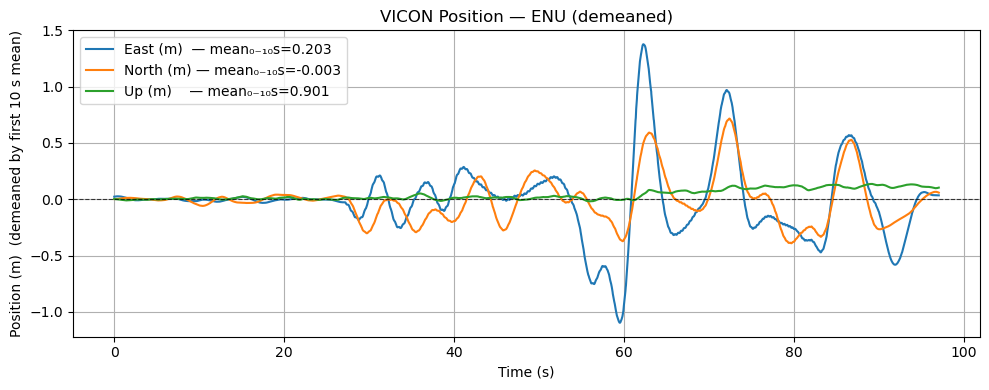

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---- time base ----
time_s = df_vicon["t_rel"].to_numpy()

def demean_first_10s(t, a):
    """Return (a_demeaned, mean_0_10s) using the first 10 s window."""
    t0 = float(t[0])
    mask10 = (t - t0) <= 10.0
    if not np.any(mask10):  # fallback if shorter than 10 s
        mask10 = np.ones_like(t, dtype=bool)
    m = float(np.nanmean(a[mask10]))
    return a - m, m

# =========================== NED plot ===========================
# Use new names if present; fall back to old ones if not.
north = df_vicon.get("pos_north_ned", df_vicon.get("pos_north")).to_numpy()
east  = df_vicon.get("pos_east_ned",  df_vicon.get("pos_east")).to_numpy()
down  = df_vicon.get("pos_down_ned",  df_vicon.get("pos_down")).to_numpy()

north_dm, mN = demean_first_10s(time_s, north)
east_dm,  mE = demean_first_10s(time_s, east)
down_dm,  mD = demean_first_10s(time_s, down)

print(f"[NED] First 10s means — North: {mN:.3f} m, East: {mE:.3f} m, Down: {mD:.3f} m")

plt.figure(figsize=(10, 4))
plt.plot(time_s, north_dm, label=f"North (m) — mean₀₋₁₀s={mN:.3f}")
plt.plot(time_s, east_dm,  label=f"East (m)  — mean₀₋₁₀s={mE:.3f}")
plt.plot(time_s, down_dm,  label=f"Down (m)  — mean₀₋₁₀s={mD:.3f}")
plt.axhline(0.0, ls='--', lw=0.8, c='k', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)  (demeaned by first 10 s mean)")
plt.title("VICON Position — NED (demeaned)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# =========================== ENU plot ===========================
east_e  = df_vicon["pos_east_enu"].to_numpy()
north_e = df_vicon["pos_north_enu"].to_numpy()
up_e    = df_vicon["pos_up_enu"].to_numpy()

east_dm_e,  mE_e  = demean_first_10s(time_s, east_e)
north_dm_e, mN_e  = demean_first_10s(time_s, north_e)
up_dm_e,    mU_e  = demean_first_10s(time_s, up_e)

print(f"[ENU] First 10s means — East: {mE_e:.3f} m, North: {mN_e:.3f} m, Up: {mU_e:.3f} m")

plt.figure(figsize=(10, 4))
plt.plot(time_s, east_dm_e,  label=f"East (m)  — mean₀₋₁₀s={mE_e:.3f}")
plt.plot(time_s, north_dm_e, label=f"North (m) — mean₀₋₁₀s={mN_e:.3f}")
plt.plot(time_s, up_dm_e,    label=f"Up (m)    — mean₀₋₁₀s={mU_e:.3f}")
plt.axhline(0.0, ls='--', lw=0.8, c='k', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)  (demeaned by first 10 s mean)")
plt.title("VICON Position — ENU (demeaned)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


[NED] First 10s means — Roll: -1.16°, Pitch: 1.32°, Yaw: 3.37°


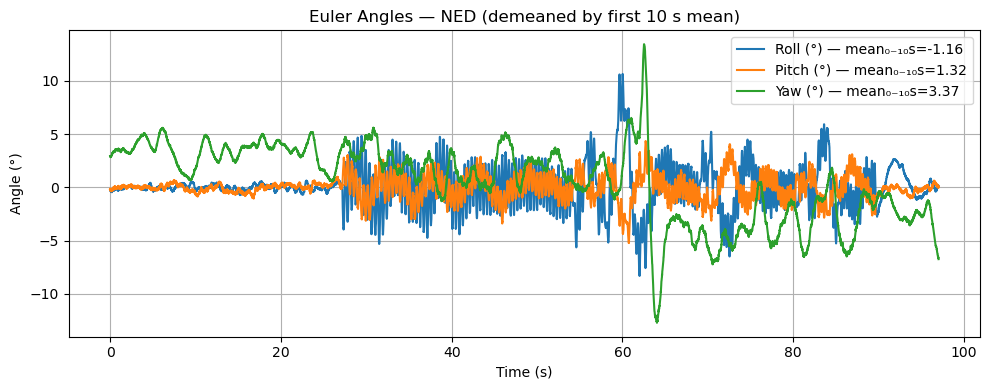

[ENU] First 10s means — Roll: -1.16°, Pitch: -1.32°, Yaw: 86.63°


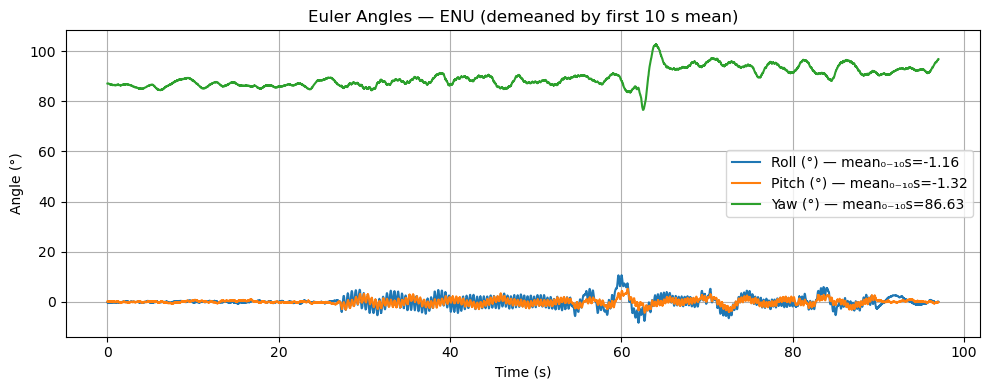

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def demean_first_10s(t, x):
    """Return (x_demeaned, mean_0_10s) using the first 10 s window."""
    t = np.asarray(t); x = np.asarray(x)
    t0 = float(t[0])
    mask10 = (t - t0) <= 10.0
    if not np.any(mask10):  # fallback if trace is shorter than 10 s
        mask10 = np.ones_like(t, dtype=bool)
    m = float(np.nanmean(x[mask10]))
    return x - m, m

def col(df_vicon, *candidates):
    """Pick the first existing column name from candidates."""
    for c in candidates:
        if c in df_vicon.columns:
            return df_vicon[c].to_numpy()
    raise KeyError(f"None of the columns exist: {candidates}")

# ---------- time base ----------
time_s = df_vicon["t_rel"].to_numpy()

# ====================== NED (FRD) angles ======================
roll_ned  = col(df_vicon, "roll_ned_deg",  "roll_deg")
pitch_ned = col(df_vicon, "pitch_ned_deg", "pitch_deg")
yaw_ned   = col(df_vicon, "yaw_ned_deg",   "yaw_deg")

roll_ned_dm,  m_rn = demean_first_10s(time_s, roll_ned)
pitch_ned_dm, m_pn = demean_first_10s(time_s, pitch_ned)
yaw_ned_dm,   m_yn = demean_first_10s(time_s, yaw_ned)   # set to yaw_ned if you prefer not to demean yaw
yaw_ned_dm = yaw_ned      # keep raw yaw

print(f"[NED] First 10s means — Roll: {m_rn:.2f}°, Pitch: {m_pn:.2f}°, Yaw: {m_yn:.2f}°")

plt.figure(figsize=(10,4))
plt.plot(time_s, roll_ned_dm,  label=f"Roll (°) — mean₀₋₁₀s={m_rn:.2f}")
plt.plot(time_s, pitch_ned_dm, label=f"Pitch (°) — mean₀₋₁₀s={m_pn:.2f}")
plt.plot(time_s, yaw_ned_dm,   label=f"Yaw (°) — mean₀₋₁₀s={m_yn:.2f}")
# plt.ylim([-10, 10])
plt.xlabel("Time (s)"); plt.ylabel("Angle (°)")
plt.title("Euler Angles — NED (demeaned by first 10 s mean)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# ====================== ENU (FLU) angles ======================
roll_enu  = col(df_vicon, "roll_enu_deg")
pitch_enu = col(df_vicon, "pitch_enu_deg")
yaw_enu   = col(df_vicon, "yaw_enu_deg")

roll_enu_dm,  m_re = demean_first_10s(time_s, roll_enu)
pitch_enu_dm, m_pe = demean_first_10s(time_s, pitch_enu)
yaw_enu_dm,   m_ye = demean_first_10s(time_s, yaw_enu)
yaw_enu_dm = yaw_enu      # keep raw yaw

print(f"[ENU] First 10s means — Roll: {m_re:.2f}°, Pitch: {m_pe:.2f}°, Yaw: {m_ye:.2f}°")

plt.figure(figsize=(10,4))
plt.plot(time_s, roll_enu_dm,  label=f"Roll (°) — mean₀₋₁₀s={m_re:.2f}")
plt.plot(time_s, pitch_enu_dm, label=f"Pitch (°) — mean₀₋₁₀s={m_pe:.2f}")
plt.plot(time_s, yaw_enu_dm,   label=f"Yaw (°) — mean₀₋₁₀s={m_ye:.2f}")
# plt.ylim([-10, 10])
plt.xlabel("Time (s)"); plt.ylabel("Angle (°)")
plt.title("Euler Angles — ENU (demeaned by first 10 s mean)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


VECHILE ODOMETRY

In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

# --- Load the CSV file ---
df_vo = pd.read_csv("/home/cpsl/px4_ws/live2_26.894_updated_param_and_manual_log60/csv_out/cpsl_uav_7__fmu__out__vehicle_odometry.csv")

# Show basic info
print("Data summary:")
df_vo.info()

# Display first few rows
df_vo.head()




Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9667 entries, 0 to 9666
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   t                     9667 non-null   float64
 1   t_rel                 9667 non-null   float64
 2   timestamp             9667 non-null   int64  
 3   timestamp_sample      9667 non-null   int64  
 4   pose_frame            9667 non-null   int64  
 5   position              9667 non-null   object 
 6   q                     9667 non-null   object 
 7   velocity_frame        9667 non-null   int64  
 8   velocity              9667 non-null   object 
 9   angular_velocity      9667 non-null   object 
 10  position_variance     9667 non-null   object 
 11  orientation_variance  9667 non-null   object 
 12  velocity_variance     9667 non-null   object 
 13  reset_counter         9667 non-null   int64  
 14  quality               9667 non-null   int64  
dtypes: floa

,t,t_rel,timestamp,timestamp_sample,pose_frame,position,q,velocity_frame,velocity,angular_velocity,position_variance,orientation_variance,velocity_variance,reset_counter,quality
0,1.762620e+09,0.113902,1762620320873119,1762620320872302,1,[-0.00182224 0.2256843 -0.8986703 ],[ 0.99951684 -0.01410448 0.00187922 0.02763688],1,[0.00121026 0.00431957 0.01256092],[-0.0227671 -0.02094089 0.01692199],[5.4917080e-05 5.4921136e-05 5.3023210e-05],[5.9586982e-05 7.0070149e-05 2.0357514e-04],[0.00061842 0.00061843 0.0005455 ],23,0
1,1.762620e+09,0.124409,1762620320883150,1762620320882319,1,[-0.0017973 0.22576435 -0.8986227 ],[ 0.9995135 -0.01417726 0.00185648 0.02772116],1,[0.00199113 0.00446231 0.01665287],[0.01081912 0.00826829 0.00983668],[5.7304031e-05 5.7308524e-05 5.5218567e-05],[5.9609662e-05 7.0084017e-05 2.0370902e-04],[0.00062995 0.00062999 0.00055685],23,0
2,1.762620e+09,0.134277,1762620320893152,1762620320892336,1,[-0.0017421 0.22585143 -0.8985895 ],[ 0.99951005 -0.01427329 0.0018125 0.02779944],1,[0.00276748 0.00478541 0.01235551],[-0.01176938 0.00414369 0.01621625],[5.9760241e-05 5.9765236e-05 5.7733745e-05],[5.9631853e-05 7.0097303e-05 2.0384177e-04],[0.00064174 0.00064177 0.00056923],23,0
3,1.762620e+09,0.144269,1762620320903208,1762620320902352,1,[-0.00171359 0.22591673 -0.8985472 ],[ 0.9995072 -0.01431796 0.00180138 0.027878 ],1,[-0.00425093 0.00301223 0.01758806],[-0.02175689 -0.00515244 0.00374738],[5.4154352e-05 5.4158241e-05 5.2242074e-05],[5.9586193e-05 7.0043920e-05 2.0356083e-04],[0.00061233 0.00061236 0.00054156],23,0
4,1.762620e+09,0.154087,1762620320913214,1762620320912410,1,[-0.00166201 0.22600578 -0.8985093 ],[ 0.9995038 -0.01437355 0.0018085 0.02797009],1,[0.00605658 0.00178 0.01207718],[-0.00215247 -0.00110824 0.02247196],[5.6499703e-05 5.6504025e-05 5.4620803e-05],[5.9608126e-05 7.0059548e-05 2.0369330e-04],[0.00062469 0.00062473 0.00055394],23,0


In [10]:
def try_cols(df_vo, names):
    """Return the first existing column from `names` as a NumPy array."""
    for n in names:
        if n in df_vo.columns:
            return df_vo[n].to_numpy()
    raise KeyError(f"None of these columns found: {names}")

def _parse_vec_series(series, expected_len):
    """
    Parse a pandas Series whose entries are vector-like strings/lists
    into a (N, expected_len) float array.
    Accepts formats like '[a, b, c]', 'a b c', 'a,b,c', '(a b c)', etc.
    """
    out = []
    for v in series.to_numpy():
        if isinstance(v, (list, tuple, np.ndarray)):
            arr = np.asarray(v, dtype=float)
        else:
            s = str(v).strip()
            # Try Python literal first: "[1, 2, 3]" or "(1, 2, 3)"
            try:
                lit = ast.literal_eval(s)
                arr = np.asarray(lit, dtype=float)
            except Exception:
                # Fallback: strip brackets and split by comma/space
                s = s.strip("[]()")
                if "," in s:
                    parts = [p for p in s.split(",") if p.strip() != ""]
                else:
                    parts = [p for p in s.split() if p.strip() != ""]
                arr = np.asarray(parts, dtype=float)
        if arr.size != expected_len:
            raise ValueError(
                f"Vector parse length mismatch: got {arr.size}, expected {expected_len}. "
                f"First bad entry: {v!r}"
            )
        out.append(arr)
    return np.vstack(out)

def vec3(df_vo, base_names):
    """
    Resolve a 3-vector with many possible naming styles.
    Returns (x, y, z) as 1D float arrays of equal length.
    """
    # Try split-column patterns first
    patterns = [
        lambda b: [f"{b}[0]", f"{b}[1]", f"{b}[2]"],
        lambda b: [f"{b}_0",  f"{b}_1",  f"{b}_2" ],
        lambda b: [f"{b}.x",  f"{b}.y",  f"{b}.z" ],
        lambda b: [f"{b}_x",  f"{b}_y",  f"{b}_z" ],
        lambda b: [f"{b}x",   f"{b}y",   f"{b}z"  ],
    ]
    tried = []
    for b in base_names:
        for pat in patterns:
            cols = pat(b)
            if all(c in df_vo.columns for c in cols):
                return (df_vo[cols[0]].to_numpy(dtype=float),
                        df_vo[cols[1]].to_numpy(dtype=float),
                        df_vo[cols[2]].to_numpy(dtype=float))
        tried.append(b)
        # Single-column fallback: e.g., column named exactly 'position'
        if b in df_vo.columns:
            arr = _parse_vec_series(df_vo[b], 3)  # (N,3)
            return arr[:,0], arr[:,1], arr[:,2]
    raise KeyError(f"Could not resolve vec3 for any base in {tried}. "
                   f"Available columns (first 20): {list(df_vo.columns)[:20]} ...")

def quat4(df_vo, base_names):
    """
    Resolve quaternion in PX4 order [w, x, y, z].
    Returns (qw, qx, qy, qz) as 1D float arrays.
    """
    patterns = [
        lambda b: [f"{b}[0]", f"{b}[1]", f"{b}[2]", f"{b}[3]"],
        lambda b: [f"{b}.w",  f"{b}.x",  f"{b}.y",  f"{b}.z" ],
        lambda b: [f"{b}_w",  f"{b}_x",  f"{b}_y",  f"{b}_z" ],
        lambda b: [f"{b}w",   f"{b}x",   f"{b}y",   f"{b}z"  ],
        lambda b: [f"{b}[w]", f"{b}[x]", f"{b}[y]", f"{b}[z]"],
    ]
    for b in base_names:
        for pat in patterns:
            cols = pat(b)
            if all(c in df_vo.columns for c in cols):
                return (df_vo[cols[0]].to_numpy(dtype=float),
                        df_vo[cols[1]].to_numpy(dtype=float),
                        df_vo[cols[2]].to_numpy(dtype=float),
                        df_vo[cols[3]].to_numpy(dtype=float))
        # Single-column fallback: e.g., column named exactly 'q'
        if b in df_vo.columns:
            arr = _parse_vec_series(df_vo[b], 4)  # (N,4) in PX4 order [w,x,y,z]
            return arr[:,0], arr[:,1], arr[:,2], arr[:,3]

    # Common alternates
    if all(c in df_vo.columns for c in ["qw","qx","qy","qz"]):
        return (df_vo["qw"].to_numpy(dtype=float), df_vo["qx"].to_numpy(dtype=float),
                df_vo["qy"].to_numpy(dtype=float), df_vo["qz"].to_numpy(dtype=float))
    if all(c in df_vo.columns for c in ["q_w","q_x","q_y","q_z"]):
        return (df_vo["q_w"].to_numpy(dtype=float), df_vo["q_x"].to_numpy(dtype=float),
                df_vo["q_y"].to_numpy(dtype=float), df_vo["q_z"].to_numpy(dtype=float))

    raise KeyError(f"Could not resolve quaternion for bases {base_names}. "
                   f"Available columns (first 20): {list(df_vo.columns)[:20]} ...")

def resolve_time_seconds(df_vo):
    """Return time in seconds, relative to first finite sample."""
    cand = ["timestamp_sample", "timestamp", "time_us", "t_us", "t", "time"]
    t_raw = try_cols(df_vo, cand)
    t = np.asarray(t_raw, dtype=float)
    if t.size == 0:
        return t
    mx = np.nanmax(t)
    if mx > 1e12:       # nanoseconds
        t = t * 1e-9
    elif mx > 1e9:      # microseconds
        t = t * 1e-6
    # make relative
    idx = np.flatnonzero(np.isfinite(t))
    if idx.size:
        t = t - t[idx[0]]
    return t

# ---------------- Resolve data ----------------
time_s = resolve_time_seconds(df_vo)

# Positions (NED by PX4 convention) -> create scalar columns
px, py, pz = vec3(df_vo, ["position", "pos", "vehicle_odometry.position", "odom.position"])
df_vo["pos_north"] = px
df_vo["pos_east"]  = py
df_vo["pos_down"]  = pz

# Linear velocity (optional)
have_vel = True
try:
    vx, vy, vz = vec3(df_vo, ["velocity", "vel", "vehicle_odometry.velocity"])
    df_vo["vel_north"] = vx
    df_vo["vel_east"]  = vy
    df_vo["vel_down"]  = vz
except KeyError:
    have_vel = False

# Angular velocity (FRD body), optional
have_rates = True
try:
    wx, wy, wz = vec3(df_vo, ["angular_velocity", "ang_vel", "gyro", "rates", "angularRate"])
    df_vo["p_deg_s"] = np.degrees(wx)
    df_vo["q_deg_s"] = np.degrees(wy)
    df_vo["r_deg_s"] = np.degrees(wz)
except KeyError:
    have_rates = False

# Quaternion -> Euler (FRD body → NED world)  -> create roll_deg/pitch_deg/yaw_deg
qw, qx, qy, qz = quat4(df_vo, ["q", "vehicle_odometry.q", "orientation", "quat"])
sinr_cosp = 2.0*(qw*qx + qy*qz)
cosr_cosp = 1.0 - 2.0*(qx*qx + qy*qy)
roll  = np.arctan2(sinr_cosp, cosr_cosp)

sinp = 2.0*(qw*qy - qz*qx)
pitch = np.where(np.abs(sinp) >= 1.0, np.sign(sinp)*np.pi/2, np.arcsin(sinp))

siny_cosp = 2.0*(qw*qz + qx*qy)
cosy_cosp = 1.0 - 2.0*(qy*qy + qz*qz)
yaw   = np.arctan2(siny_cosp, cosy_cosp)

df_vo["roll_deg"]  = np.degrees(roll)
df_vo["pitch_deg"] = np.degrees(pitch)
df_vo["yaw_deg"]   = np.degrees(np.unwrap(yaw))

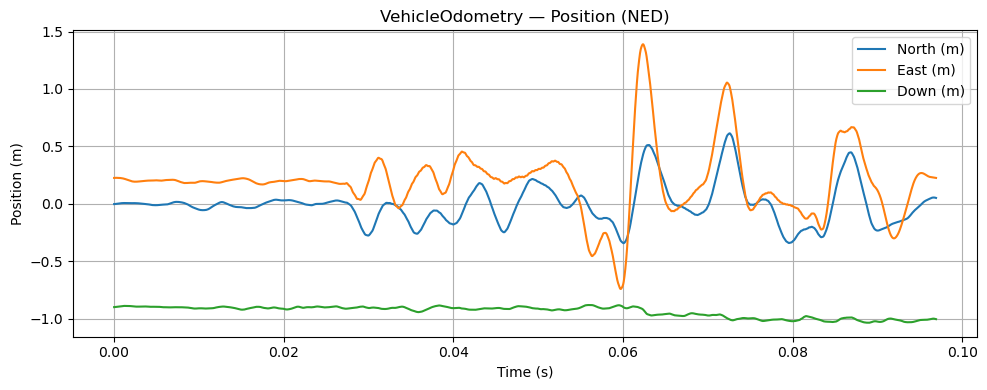

In [11]:
# ===================== PLOTS =====================

# (1) Position (NED)
plt.figure(figsize=(10,4))
plt.plot(time_s, df_vo["pos_north"].to_numpy(), label="North (m)")
plt.plot(time_s, df_vo["pos_east"].to_numpy(),  label="East (m)")
plt.plot(time_s, df_vo["pos_down"].to_numpy(),  label="Down (m)")
plt.xlabel("Time (s)"); plt.ylabel("Position (m)")
plt.title("VehicleOdometry — Position (NED)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


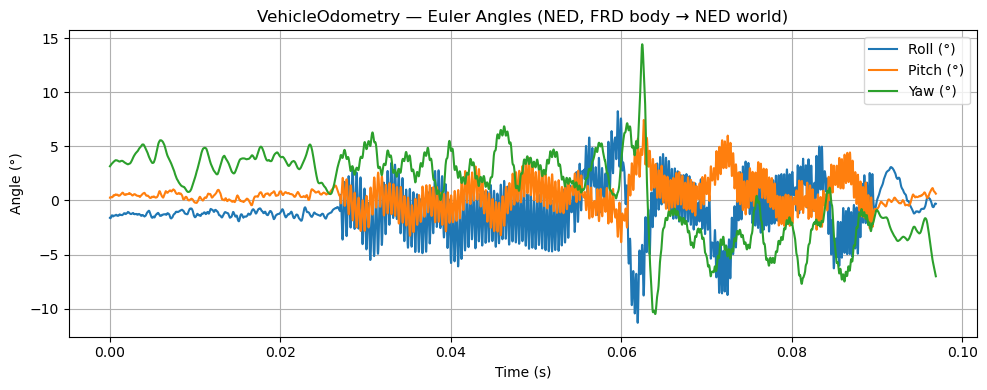

In [12]:
# (2) Euler angles (deg) — robust plotting (no axes handle; unique var names)
roll_deg_eul  = np.asarray(df_vo["roll_deg"],  dtype=float)
pitch_deg_eul = np.asarray(df_vo["pitch_deg"], dtype=float)
yaw_deg_eul   = np.asarray(df_vo["yaw_deg"],   dtype=float)

# Ensure same length
n_eul = min(time_s.size, roll_deg_eul.size, pitch_deg_eul.size, yaw_deg_eul.size)
t_eul = np.asarray(time_s[:n_eul], dtype=float)
roll_deg_eul  = roll_deg_eul[:n_eul]
pitch_deg_eul = pitch_deg_eul[:n_eul]
yaw_deg_eul   = yaw_deg_eul[:n_eul]

# Drop NaNs/Infs consistently
mask_eul = (
    np.isfinite(t_eul) &
    np.isfinite(roll_deg_eul) &
    np.isfinite(pitch_deg_eul) &
    np.isfinite(yaw_deg_eul)
)
t_eul          = t_eul[mask_eul]
roll_deg_eul   = roll_deg_eul[mask_eul]
pitch_deg_eul  = pitch_deg_eul[mask_eul]
yaw_deg_eul    = yaw_deg_eul[mask_eul]

# Plot using pyplot only
plt.figure(figsize=(10, 4))
plt.plot(t_eul, roll_deg_eul,  label="Roll (°)")
plt.plot(t_eul, pitch_deg_eul, label="Pitch (°)")
plt.plot(t_eul, yaw_deg_eul,   label="Yaw (°)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (°)")
plt.title("VehicleOdometry — Euler Angles (NED, FRD body → NED world)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


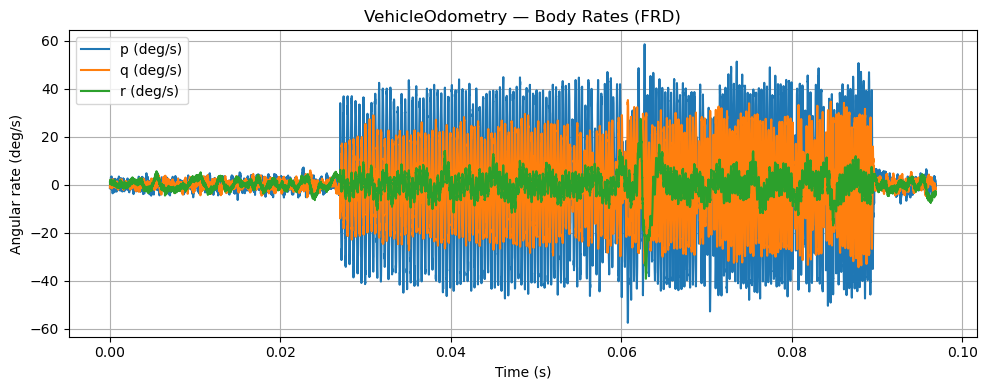

In [13]:
# (3) Angular rates (deg/s) — robust plotting (no axes handle; unique var names)
if have_rates and all(c in df_vo.columns for c in ["p_deg_s", "q_deg_s", "r_deg_s"]):
    p_deg_rates = np.asarray(df_vo["p_deg_s"], dtype=float)
    q_deg_rates = np.asarray(df_vo["q_deg_s"], dtype=float)
    r_deg_rates = np.asarray(df_vo["r_deg_s"], dtype=float)

    # Align series lengths
    n_rates = min(time_s.size, p_deg_rates.size, q_deg_rates.size, r_deg_rates.size)
    t_rates = np.asarray(time_s[:n_rates], dtype=float)
    p_deg_rates = p_deg_rates[:n_rates]
    q_deg_rates = q_deg_rates[:n_rates]
    r_deg_rates = r_deg_rates[:n_rates]

    # Drop rows with NaNs/Infs
    mask_rates = (
        np.isfinite(t_rates) &
        np.isfinite(p_deg_rates) &
        np.isfinite(q_deg_rates) &
        np.isfinite(r_deg_rates)
    )
    t_rates      = t_rates[mask_rates]
    p_deg_rates  = p_deg_rates[mask_rates]
    q_deg_rates  = q_deg_rates[mask_rates]
    r_deg_rates  = r_deg_rates[mask_rates]

    # Plot using pyplot only
    plt.figure(figsize=(10, 4))
    plt.plot(t_rates, p_deg_rates, label="p (deg/s)")
    plt.plot(t_rates, q_deg_rates, label="q (deg/s)")
    plt.plot(t_rates, r_deg_rates, label="r (deg/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular rate (deg/s)")
    plt.title("VehicleOdometry — Body Rates (FRD)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No angular-rate columns found; skipped body-rate plot.")


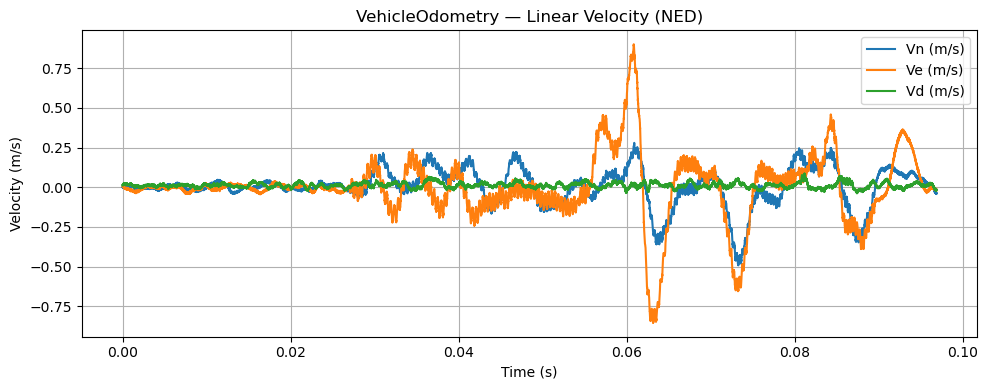

In [14]:
# (4) Linear velocity (NED, m/s) — robust plotting (no axes handle; unique var names)
if have_vel and all(c in df_vo.columns for c in ["vel_north", "vel_east", "vel_down"]):
    vn_vel = np.asarray(df_vo["vel_north"], dtype=float)
    ve_vel = np.asarray(df_vo["vel_east"],  dtype=float)
    vd_vel = np.asarray(df_vo["vel_down"],  dtype=float)

    # Align series lengths
    n_vel = min(time_s.size, vn_vel.size, ve_vel.size, vd_vel.size)
    t_vel = np.asarray(time_s[:n_vel], dtype=float)
    vn_vel, ve_vel, vd_vel = vn_vel[:n_vel], ve_vel[:n_vel], vd_vel[:n_vel]

    # Drop rows with NaNs/Infs
    mask_vel = (
        np.isfinite(t_vel) &
        np.isfinite(vn_vel) &
        np.isfinite(ve_vel) &
        np.isfinite(vd_vel)
    )
    t_vel  = t_vel[mask_vel]
    vn_vel = vn_vel[mask_vel]
    ve_vel = ve_vel[mask_vel]
    vd_vel = vd_vel[mask_vel]

    # Plot using pyplot only
    plt.figure(figsize=(10, 4))
    plt.plot(t_vel, vn_vel, label="Vn (m/s)")
    plt.plot(t_vel, ve_vel, label="Ve (m/s)")
    plt.plot(t_vel, vd_vel, label="Vd (m/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.title("VehicleOdometry — Linear Velocity (NED)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No velocity columns found; skipped linear-velocity plot.")


SENSOR_COMBINED

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

# --- Load the CSV file ---
df_sensor = pd.read_csv("/home/cpsl/px4_ws/live2_26.894_updated_param_and_manual_log60/csv_out/cpsl_uav_7__fmu__out__sensor_combined.csv")

# Show basic info
print("Data summary:")
df_sensor.info()

# Display first few rows
df_sensor.head()




Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9691 entries, 0 to 9690
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   t                                 9691 non-null   float64
 1   t_rel                             9691 non-null   float64
 2   timestamp                         9691 non-null   int64  
 3   gyro_rad                          9691 non-null   object 
 4   gyro_integral_dt                  9691 non-null   int64  
 5   accelerometer_timestamp_relative  9691 non-null   int64  
 6   accelerometer_m_s2                9691 non-null   object 
 7   accelerometer_integral_dt         9691 non-null   int64  
 8   accelerometer_clipping            9691 non-null   int64  
 9   gyro_clipping                     9691 non-null   int64  
 10  accel_calibration_count           9691 non-null   int64  
 11  gyro_calibration_count            9691 non-null   int64

,t,t_rel,timestamp,gyro_rad,gyro_integral_dt,accelerometer_timestamp_relative,accelerometer_m_s2,accelerometer_integral_dt,accelerometer_clipping,gyro_clipping,accel_calibration_count,gyro_calibration_count
0,1.762620e+09,0.108513,1762620320867295,[ 0.00269541 -0.01757795 0.01660043],2504,0,[ 0.11537793 -1.010591 -9.58415 ],2504,0,0,2,1
1,1.762620e+09,0.118840,1762620320877311,[-0.01803936 -0.00570286 0.02930868],2505,0,[-0.8291443 1.4186227 -9.122055 ],2505,0,0,2,1
2,1.762620e+09,0.128644,1762620320887327,[-0.04805675 -0.02072076 0.01285065],2504,0,[ 1.2835518 0.9194562 -9.991492 ],2504,0,0,2,1
3,1.762620e+09,0.138724,1762620320897344,[-0.0221026 -0.00331811 0.02459106],2503,0,[-0.09679449 -1.1682673 -8.189757 ],2503,0,0,2,1
4,1.762620e+09,0.149082,1762620320907361,[-0.01379659 0.00515119 0.02697219],2505,0,[ -0.07741429 1.2450212 -11.221477 ],2505,0,0,2,1


In [16]:
# 2) Time base in seconds  ---------------------------------------------------
def get_time_seconds(df_sensor):
    # Prefer t_rel if available; otherwise infer µs
    if "t_rel" in df_sensor.columns:
        t = df_sensor["t_rel"].to_numpy(dtype=float)
        return t - t[0]
    for c in ["timestamp_sample", "timestamp", "time_us", "t_us"]:
        if c in df_sensor.columns:
            t = df_sensor[c].to_numpy(dtype=float)
            return (t - t[0]) * 1e-6
    raise KeyError("No time column found (t_rel/timestamp_sample/timestamp/time_us/t_us).")

time_s = get_time_seconds(df_sensor)


In [17]:
# 3) Vector column parser  ---------------------------------------------------
def split_vec_col(series: pd.Series):
    """
    Convert strings like "[a b c]" or "[a, b, c]" into 3 float arrays.
    Uses numpy.fromstring so it's robust to spaces/commas.
    """
    xs, ys, zs = [], [], []
    for s in series.astype(str):
        vals = np.fromstring(s.strip('[]'), sep=' ')
        if vals.size < 3:
            vals = np.fromstring(s.strip('[]'), sep=',')
        if vals.size >= 3:
            xs.append(vals[0]); ys.append(vals[1]); zs.append(vals[2])
        else:
            xs.append(np.nan); ys.append(np.nan); zs.append(np.nan)
    return np.array(xs, float), np.array(ys, float), np.array(zs, float)

In [18]:
# 4) Extract IMU signals  ----------------------------------------------------
# PX4 sensor_combined typically stores these as bracketed strings
ax, ay, az = split_vec_col(df_sensor["accelerometer_m_s2"])
gx, gy, gz = split_vec_col(df_sensor["gyro_rad"])

# Convert gyro rad/s -> deg/s for readability
p_deg_s = np.degrees(gx)
q_deg_s = np.degrees(gy)
r_deg_s = np.degrees(gz)


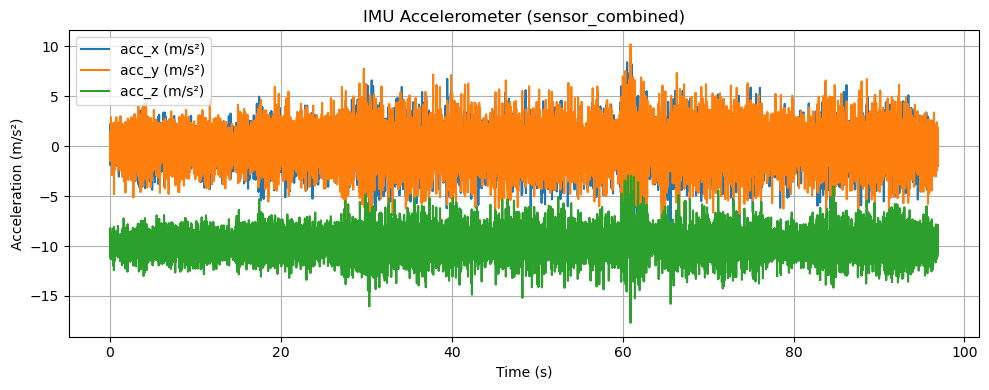

In [19]:

# 5) Plots (each chart in its own figure)  ----------------------------------
plt.figure(figsize=(10, 4))
plt.plot(time_s, ax, label="acc_x (m/s²)")
plt.plot(time_s, ay, label="acc_y (m/s²)")
plt.plot(time_s, az, label="acc_z (m/s²)")
plt.xlabel("Time (s)"); plt.ylabel("Acceleration (m/s²)")
plt.title("IMU Accelerometer (sensor_combined)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


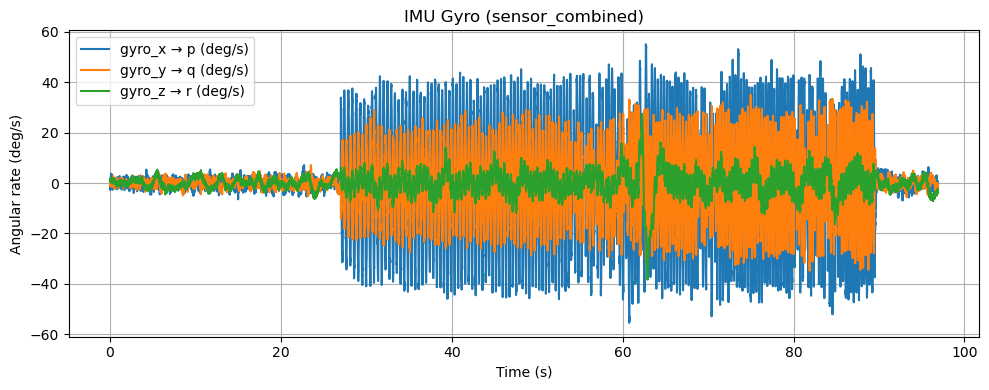

In [20]:

plt.figure(figsize=(10, 4))
plt.plot(time_s, p_deg_s, label="gyro_x → p (deg/s)")
plt.plot(time_s, q_deg_s, label="gyro_y → q (deg/s)")
plt.plot(time_s, r_deg_s, label="gyro_z → r (deg/s)")
plt.xlabel("Time (s)"); plt.ylabel("Angular rate (deg/s)")
plt.title("IMU Gyro (sensor_combined)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

Overall

In [21]:
import numpy as np
import ast  # only needed if you use vector parsers elsewhere

def time_seconds(df):
    """Pick a time column, convert to seconds, and make relative to first sample."""
    for c in ("t_rel", "timestamp_sample", "timestamp", "time_us"):
        if c in df.columns:
            t = df[c].to_numpy(dtype=float)
            if c in ("timestamp_sample", "timestamp", "time_us"):
                t *= 1e-6  # µs→s
            idx = np.flatnonzero(np.isfinite(t))
            return t - t[idx[0]] if idx.size else t
    raise KeyError("No time column found.")

def interp_to_ref(t_ref, t_src, y_src):
    """
    Interpolate y_src(t_src) onto t_ref.
    Cleans NaNs, sorts, deduplicates t_src; pads NaN outside range.
    Also trims if t_src and y_src lengths differ.
    """
    t_ref = np.asarray(t_ref, dtype=float)
    t_src = np.asarray(t_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)

    # If lengths differ, trim to the shorter one (keeps time/data pairing)
    if t_src.shape[0] != y_src.shape[0]:
        n = min(t_src.shape[0], y_src.shape[0])
        t_src = t_src[:n]
        y_src = y_src[:n]

    # Remove non-finite
    m = np.isfinite(t_src) & np.isfinite(y_src)
    t_src = t_src[m]; y_src = y_src[m]
    if t_src.size < 2:
        return np.full_like(t_ref, np.nan, dtype=float)

    # Sort by time
    order = np.argsort(t_src)
    t_src = t_src[order]; y_src = y_src[order]

    # Deduplicate times (keep first occurrence)
    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_ref, t_unique, y_unique, left=np.nan, right=np.nan)

# ---------------- time from each source ----------------
t_vo     = time_seconds(df_vo)       # vehicle_odometry CSV
t_vicon  = time_seconds(df_vicon)    # Vicon CSV
t_sensor = time_seconds(df_sensor)   # sensor_combined CSV (for p_deg_rates)

# choose a common reference time axis (e.g., sensor_combined)
t_ref = t_sensor

# ---------------- interpolate each signal to t_ref ----------------
# From Vicon:
pitch_ned_vic_i = interp_to_ref(t_ref, t_vicon, pitch_ned_dm.astype(float))
roll_ned_vic_i  = interp_to_ref(t_ref, t_vicon, roll_ned_dm.astype(float))
east_vic_i      = interp_to_ref(t_ref, t_vicon, east_dm.astype(float))

# From vehicle_odometry:
roll_vo_i = interp_to_ref(t_ref, t_vo, df_vo["roll_deg"].to_numpy(dtype=float))
east_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pos_east"].to_numpy(dtype=float))

# From sensor_combined (ensure same base as t_sensor):
p_deg_rates_i = interp_to_ref(t_ref, t_sensor, p_deg_rates.astype(float))

# Sanity print
print("Shapes:",
      "t_ref", t_ref.shape,
      "pitch_ned_vic_i", pitch_ned_vic_i.shape,
      "roll_ned_vic_i", roll_ned_vic_i.shape,
      "roll_vo_i", roll_vo_i.shape,
      "east_vo_i", east_vo_i.shape,
      "east_vic_i", east_vic_i.shape,
      "p_deg_rates_i", p_deg_rates_i.shape)


Shapes: t_ref (9691,) pitch_ned_vic_i (9691,) roll_ned_vic_i (9691,) roll_vo_i (9691,) east_vo_i (9691,) east_vic_i (9691,) p_deg_rates_i (9691,)


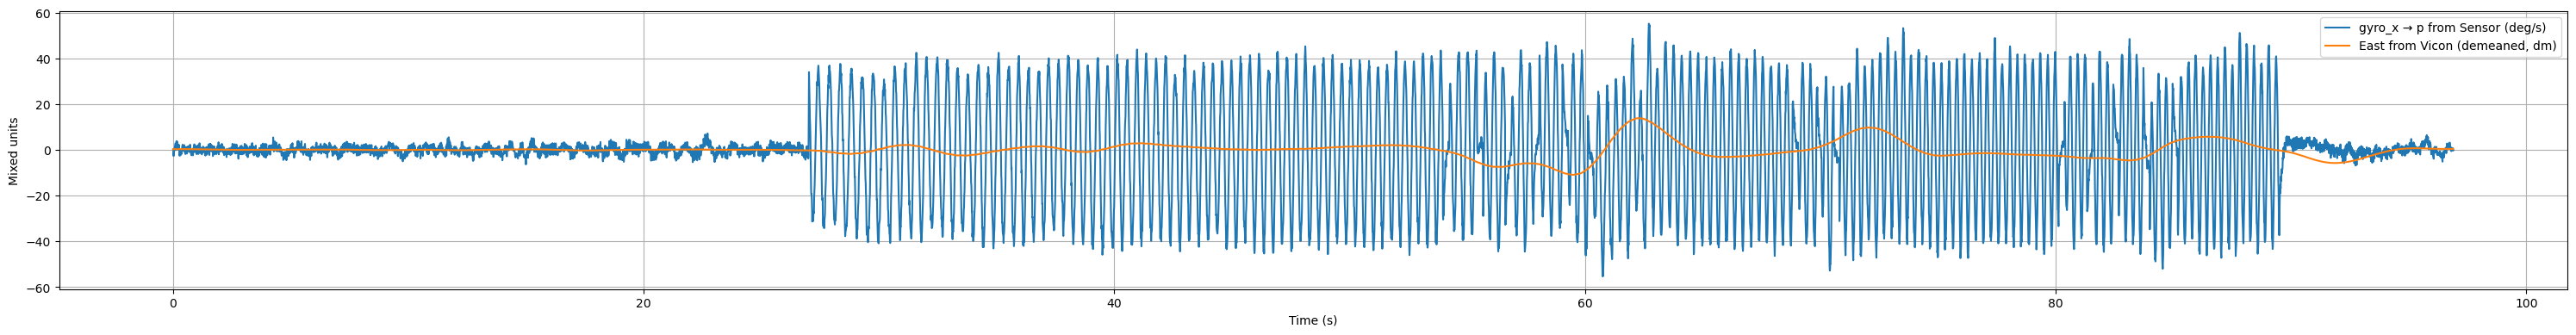

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 4))
plt.plot(time_s, p_deg_s,    label="gyro_x → p from Sensor (deg/s)")
# plt.plot(time_s, p_deg_rates_i,    label="gyro_x → p from VO (deg/s)")
# plt.plot(time_s, roll_vo_i,  label="Roll (deg) from VO EKF")
# plt.plot(time_s, roll_ned_vic_i, label="Roll (deg) from Vicon")
# plt.plot(time_s, 10*east_vo_i,  label="East from VO (dm)")
plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)")
# plt.ylim(-10, 10)
plt.xlabel("Time (s)"); plt.ylabel("Mixed units")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [28]:
# ---------- Interpolate NORTH & PITCH to t_ref ----------

# ---- Vicon sources (robust fallbacks) ----
# north: use demeaned if you already computed it; else raw pos_north
if 'north_dm' in globals():
    north_vicon_src = np.asarray(north_dm, dtype=float)
elif "pos_north" in df_vicon.columns:
    north_vicon_src = df_vicon["pos_north"].to_numpy(dtype=float)
else:
    raise KeyError("Need Vicon north: provide `north_dm` or df_vicon['pos_north'].")

# pitch: use your demeaned pitch if present; else look for a Vicon pitch col (deg)
if 'pitch_ned_dm' in globals():
    pitch_vicon_src_deg = np.asarray(pitch_ned_dm, dtype=float)
elif "pitch_deg" in df_vicon.columns:
    pitch_vicon_src_deg = df_vicon["pitch_deg"].to_numpy(dtype=float)
else:
    raise KeyError("Need Vicon pitch: provide `pitch_ned_dm` or df_vicon['pitch_deg'].")

# Interpolate Vicon to the common time base
north_vic_i  = interp_to_ref(t_ref, t_vicon, north_vicon_src)
pitch_vic_i  = interp_to_ref(t_ref, t_vicon, pitch_vicon_src_deg)

# ---- VO (vehicle_odometry) sources ----
if "pos_north" not in df_vo.columns:
    raise KeyError("df_vo must contain 'pos_north' for VO north position.")
if "pitch_deg" not in df_vo.columns:
    raise KeyError("df_vo must contain 'pitch_deg' (computed earlier from quaternion).")

north_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pos_north"].to_numpy(dtype=float))
pitch_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pitch_deg"].to_numpy(dtype=float))

# Alias for plotting to match your earlier code
time_s = np.asarray(t_ref, dtype=float)

# Quick sanity
print("Interpolated arrays:")
print("  north_vic_i:", north_vic_i.shape, " pitch_vic_i:", pitch_vic_i.shape)
print("  north_vo_i :", north_vo_i.shape,  " pitch_vo_i :", pitch_vo_i.shape)


Interpolated arrays:
  north_vic_i: (9691,)  pitch_vic_i: (9691,)
  north_vo_i : (9691,)  pitch_vo_i : (9691,)


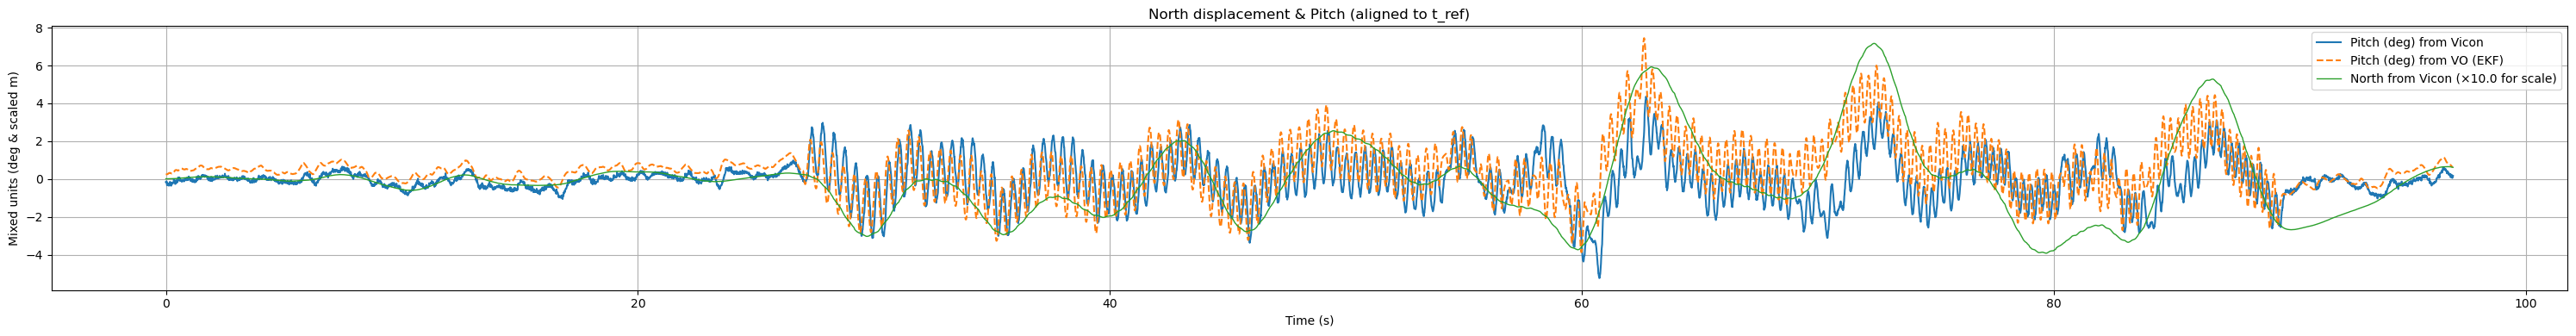

In [29]:
import matplotlib.pyplot as plt

SCALE_NORTH = 10.0  # scale meters -> decimeters for overplotting with degrees

plt.figure(figsize=(30, 4))
plt.plot(time_s, pitch_vic_i,        label="Pitch (deg) from Vicon", lw=1.5)
plt.plot(time_s, pitch_vo_i,         label="Pitch (deg) from VO (EKF)", lw=1.5, ls='--')
plt.plot(time_s, SCALE_NORTH*north_vic_i, label=f"North from Vicon (×{SCALE_NORTH} for scale)", lw=1.0)
# plt.plot(time_s, SCALE_NORTH*north_vo_i,  label=f"North from VO (×{SCALE_NORTH} for scale)",   lw=1.0, ls='--')

plt.xlabel("Time (s)")
plt.ylabel("Mixed units (deg & scaled m)")
plt.title("North displacement & Pitch (aligned to t_ref)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== Core helpers =====================

def moving_average(x, win_samples: int):
    """Simple centered moving average (same-size output)."""
    win = int(max(1, win_samples))
    if win == 1:
        return np.asarray(x, float)
    k = np.ones(win, float) / win
    return np.convolve(np.asarray(x, float), k, mode="same")

def interp_to_ref(t_ref, t_src, y_src):
    """
    Interpolate y_src(t_src) onto t_ref.
    Cleans NaNs, sorts, deduplicates times; pads with NaN outside range.
    """
    t_ref = np.asarray(t_ref, float)
    t_src = np.asarray(t_src, float)
    y_src = np.asarray(y_src, float)

    # align lengths if a logger dropped samples in one of the arrays
    n = min(t_src.size, y_src.size)
    t_src, y_src = t_src[:n], y_src[:n]

    m = np.isfinite(t_src) & np.isfinite(y_src)
    t_src, y_src = t_src[m], y_src[m]
    if t_src.size < 2:
        return np.full_like(t_ref, np.nan, float)

    order = np.argsort(t_src)
    t_src, y_src = t_src[order], y_src[order]

    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_ref, t_unique, y_unique, left=np.nan, right=np.nan)

def cycle_bounds_from_signal(
    t, y, *, osc_smooth_s=0.03, trend_s=0.50
):
    """
    Detect oscillation cycles via positive-going zero crossings of a
    smoothed+detrended version of y.

    Returns:
      tc      : (K,) time at center of each cycle
      bounds  : list[(i0, i1)] index bounds over ORIGINAL arrays (inclusive end)
      trend   : slow baseline used for detrending (same length as y)
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), [], np.full_like(t, np.nan, float)

    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return np.array([]), [], np.full_like(t, np.nan, float)

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s   / dt)) | 1)   # force odd

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    s = np.sign(osc)
    s[s == 0] = 1
    zc_pos = np.where((s[:-1] < 0) & (s[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), [], trend

    tc, bounds = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        # use interior of each cycle [i0+1, i1]
        if (i1 - i0) >= 2:
            bounds.append((i0+1, i1))
            tc.append(0.5*(t[i0+1] + t[i1]))

    return np.asarray(tc), bounds, trend

def per_cycle_mean_from_bounds(y, bounds):
    """Return per-cycle mean of y over the provided bounds list[(i0,i1)]."""
    y = np.asarray(y, float)
    means = []
    for i0, i1 in bounds:
        seg = y[i0:i1+1]
        means.append(np.nan if seg.size == 0 else float(np.nanmean(seg)))
    return np.asarray(means, float)

# ===================== Plotting APIs =====================

def plot_cycle_mean(
    t, y, *,
    label="signal",
    color=None,
    use_reference=None,
    osc_smooth_s=0.03,
    trend_s=0.50,
    show_raw=True,
    raw_alpha=0.25,
    step_kwargs=None,
    scatter_kwargs=None,
):
    """
    Plot raw series (optional) plus per-cycle means (as steps+markers).
    If use_reference is provided as a (t_ref, y_ref) pair, cycles are segmented
    on that reference but means are computed on y. Otherwise y self-segments.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    n = min(t.size, y.size)
    t, y = t[:n], y[:n]

    if use_reference is None:
        tc, bounds, _ = cycle_bounds_from_signal(t, y, osc_smooth_s=osc_smooth_s, trend_s=trend_s)
    else:
        t_ref, y_ref = use_reference
        t_ref = np.asarray(t_ref, float)
        y_ref = np.asarray(y_ref, float)
        nref  = min(t_ref.size, y_ref.size)
        t_ref, y_ref = t_ref[:nref], y_ref[:nref]
        tc, bounds, _ = cycle_bounds_from_signal(t_ref, y_ref, osc_smooth_s=osc_smooth_s, trend_s=trend_s)

        # Convert reference time centers to indices on our t for plotting markers/steps
        # (we'll just use tc as x for the means; means are computed from bounds on y)
    means = per_cycle_mean_from_bounds(y, bounds)

    # Plot
    if show_raw:
        plt.plot(t, y, lw=0.9, alpha=raw_alpha, color=color, label=f"{label} (raw)")

    step_kwargs  = {} if step_kwargs is None else dict(step_kwargs)
    scatter_kwargs = {} if scatter_kwargs is None else dict(scatter_kwargs)

    plt.step(tc, means, where="mid", lw=2.0, color=color, label=f"{label} — cycle mean", **step_kwargs)
    plt.scatter(tc, means, s=20, zorder=3, color=color, **scatter_kwargs)

    return tc, means  # handy if you want to compute further stats

def plot_multi_cycle_means(
    t, series_dict,
    *,
    reference_label=None,
    independent=False,
    osc_smooth_s=0.03,
    trend_s=0.50,
    show_raw=True,
):
    """
    series_dict: {label: y}
    If independent=False: cycles are taken from the reference (first key or reference_label).
    If independent=True: each series is segmented independently.
    """
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)

    if not independent:
        if reference_label is None:
            reference_label = next(iter(series_dict.keys()))
        tcref, bounds, _ = cycle_bounds_from_signal(
            t, series_dict[reference_label], osc_smooth_s=osc_smooth_s, trend_s=trend_s
        )

        for i, (lbl, y) in enumerate(series_dict.items()):
            color = None if colors is None else colors[i % len(colors)]
            if show_raw:
                plt.plot(t[:len(y)], y[:len(y)], lw=0.9, alpha=0.25, color=color, label=f"{lbl} (raw)")
            means = per_cycle_mean_from_bounds(y, bounds)
            plt.step(tcref, means, where="mid", lw=2.0, color=color, label=f"{lbl} — cycle mean")
            plt.scatter(tcref, means, s=20, zorder=3, color=color)
        return

    # independent segmentation per series
    for i, (lbl, y) in enumerate(series_dict.items()):
        color = None if colors is None else colors[i % len(colors)]
        if show_raw:
            plt.plot(t[:len(y)], y[:len(y)], lw=0.9, alpha=0.25, color=color, label=f"{lbl} (raw)")
        tc, bounds, _ = cycle_bounds_from_signal(t, y, osc_smooth_s=osc_smooth_s, trend_s=trend_s)
        means = per_cycle_mean_from_bounds(y, bounds)
        plt.step(tc, means, where="mid", lw=2.0, color=color, label=f"{lbl} — cycle mean")
        plt.scatter(tc, means, s=20, zorder=3, color=color)


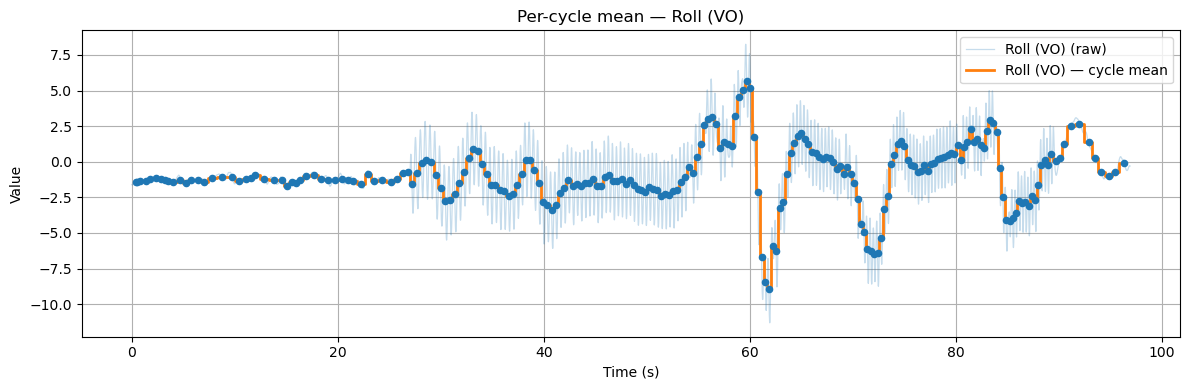

In [31]:
plt.figure(figsize=(12,4))
tc_roll, m_roll = plot_cycle_mean(time_s, roll_vo_i, label="Roll (VO)", osc_smooth_s=0.04, trend_s=0.6)
plt.xlabel("Time (s)"); plt.ylabel("Value"); plt.title("Per-cycle mean — Roll (VO)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


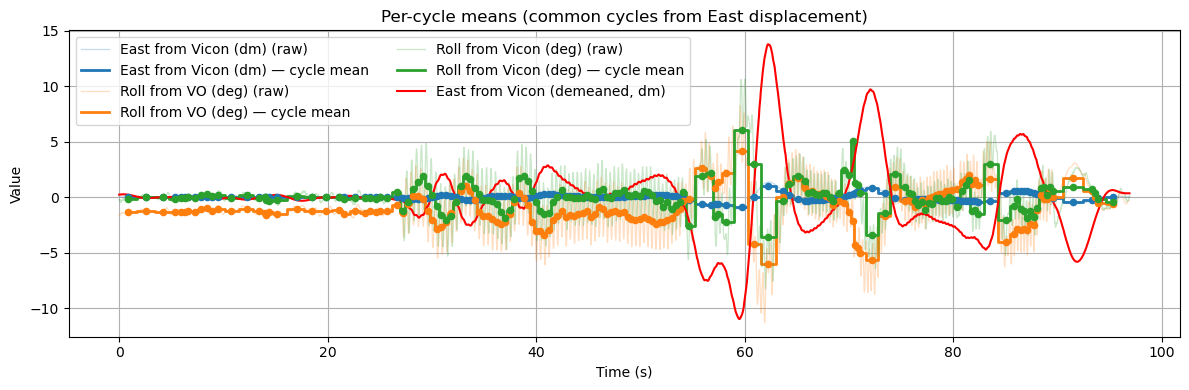

In [41]:
plt.figure(figsize=(12,4))
plot_multi_cycle_means(
    time_s,
    {
        "East from Vicon (dm)": east_vic_i,
        # "gyro_x → p from Sensor (deg/s)": p_deg_s,
        "Roll from VO (deg)":    roll_vo_i,
        "Roll from Vicon (deg)": roll_ned_vic_i,
        # "Roll Vicon-Roll VO (deg)": roll_ned_vic_i-roll_vo_i,
    },
    # reference_label="East from Vicon (dm)",
    osc_smooth_s=0.04, trend_s=0.6, show_raw=True
)
plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)", color="red")
plt.xlabel("Time (s)"); plt.ylabel("Value")
plt.title("Per-cycle means (common cycles from East displacement)")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout(); plt.show()


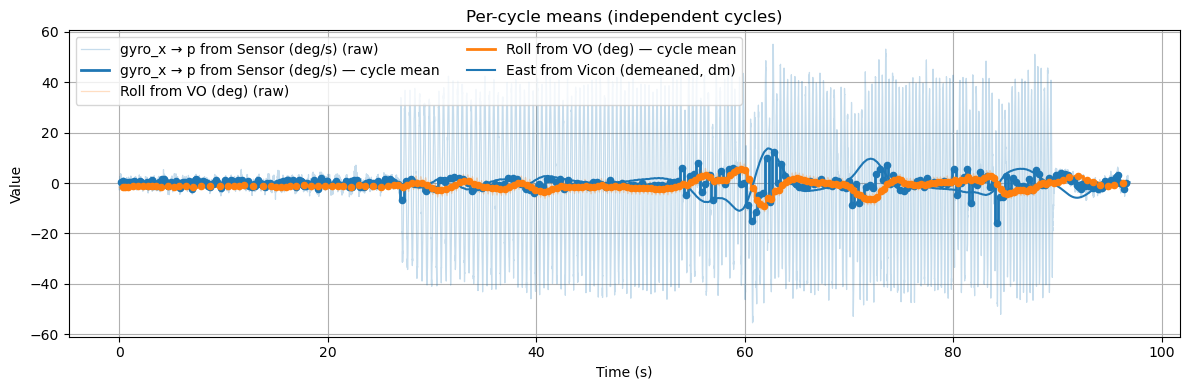

In [33]:
plt.figure(figsize=(12,4))
plot_multi_cycle_means(
    time_s,
    {
        "gyro_x → p from Sensor (deg/s)": p_deg_s,
        "Roll from VO (deg)":    roll_vo_i,
        # "Roll from Vicon (deg)": roll_ned_vic_i,
        # "Pitch from Vicon (deg)": pitch_ned_vic_i,
    },
    independent=True,
    osc_smooth_s=0.04, trend_s=0.6, show_raw=True
)
plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)")
plt.xlabel("Time (s)"); plt.ylabel("Value")
plt.title("Per-cycle means (independent cycles)")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout(); plt.show()


paper figures

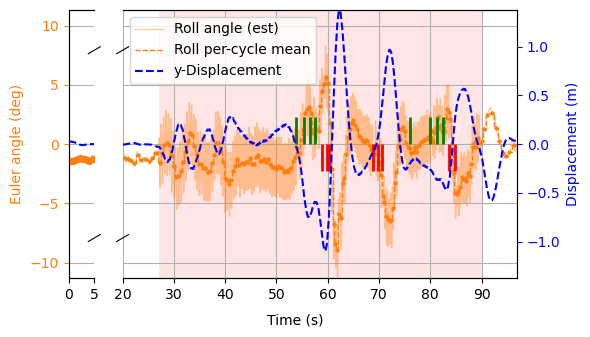

In [26]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- color config ----------
roll_color = 'tab:orange'   # EKF roll + means

# ---------- helpers for per-cycle means ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    """
    Compute per-cycle means of y(t) where cycles are defined
    by positive-going zero crossings of a smoothed & detrended
    version of the signal.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), []

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), []

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), []

    tc, means, idxs = [], [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
        idxs.append((i0+1, i1))

    return np.asarray(tc), np.asarray(means), idxs

# ---------- compute per-cycle means for EKF roll ----------
tc_roll, m_roll, _ = per_cycle_means(
    time_s,
    roll_vo_i,
    osc_smooth_s=0.04,
    trend_s=0.6
)

# ---------- broken-axis setup ----------
T_CUT_LOW  = 5.0
T_CUT_HIGH = 20.0

mask_left  = time_s <= T_CUT_LOW
mask_right = time_s >= T_CUT_HIGH

if not (mask_left.any() and mask_right.any()):
    raise ValueError("Cut interval must lie inside the time range.")

t_left_min  = float(time_s[0])
t_left_max  = T_CUT_LOW
t_right_min = T_CUT_HIGH
t_right_max = float(time_s[-1])

span_left  = t_left_max  - t_left_min
span_right = t_right_max - t_right_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 3.5),
    gridspec_kw={'width_ratios': [span_left, span_right]}
)

fig.subplots_adjust(wspace=0.12, bottom=0.18)

# twin axes for EAST
ax1_r = ax1.twinx()
ax2_r = ax2.twinx()

# ---------- LEFT PANEL ----------
# EKF roll (background, semi-transparent)
line_roll, = ax1.plot(
    time_s[mask_left],
    roll_vo_i[mask_left],
    color=roll_color,
    alpha=0.4,          # transparency so means stand out
    linewidth=1.0,
    label="Roll angle (est)",
)

# Per-cycle means (step + dots) on left panel
mask_tc_left = tc_roll <= T_CUT_LOW
line_mean_left, = ax1.step(       # note the comma to unpack single Line2D
    tc_roll[mask_tc_left],
    m_roll[mask_tc_left],
    where='mid',
    color=roll_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Roll per-cycle mean"
)
ax1.scatter(
    tc_roll[mask_tc_left],
    m_roll[mask_tc_left],
    s=18,
    color=roll_color,
    marker='o',
    zorder=3
)

# East from Vicon (blue, right twin – axis hidden here)
east_left = east_vic_i[mask_left]
line_east, = ax1_r.plot(
    time_s[mask_left],
    east_left,
    color='b',
    linestyle='--',
    label="y-displacement",
)

ax1.set_xlim(t_left_min, t_left_max)
ax1.set_ylabel("Euler angle (deg)")
ax1.grid(True)

# hide right y-axis of left panel’s twin
ax1_r.spines["right"].set_visible(False)
ax1_r.tick_params(right=False, labelright=False)

# ---------- RIGHT PANEL ----------
# EKF roll (background)
ax2.plot(
    time_s[mask_right],
    roll_vo_i[mask_right],
    color=roll_color,
    alpha=0.4,
    linewidth=1.0
)

# Per-cycle means on right panel
mask_tc_right = tc_roll >= T_CUT_HIGH
ax2.step(
    tc_roll[mask_tc_right],
    m_roll[mask_tc_right],
    where='mid',
    color=roll_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_roll[mask_tc_right],
    m_roll[mask_tc_right],
    s=18,
    color=roll_color,
    marker='.',
    zorder=2
)

# East (blue, dashed) on right twin
east_right = east_vic_i[mask_right]
ax2_r.plot(
    time_s[mask_right],
    east_right,
    color='b',
    linestyle='--'
)

ax2.set_xlim(t_right_min, t_right_max)
ax2.grid(True)
ax2_r.set_ylabel("Displacement (m)")

# ---------- MATCH Y LIMITS (ALIGN ZERO ON BOTH AXES) ----------
# Roll (left axes): symmetric around 0
roll_left  = roll_vo_i[mask_left]
roll_right = roll_vo_i[mask_right]
roll_all = np.concatenate([roll_left, roll_right, m_roll[np.isfinite(m_roll)]])
roll_abs = np.nanmax(np.abs(roll_all))
r_min, r_max = -roll_abs, roll_abs
ax1.set_ylim(r_min, r_max)
ax2.set_ylim(r_min, r_max)

# East (right axes): symmetric around 0
east_all = np.concatenate([east_left, east_right])
east_abs = np.nanmax(np.abs(east_all))
e_min, e_max = -east_abs, east_abs
ax1_r.set_ylim(e_min, e_max)
ax2_r.set_ylim(e_min, e_max)

# color axes to match curves
ax1.tick_params(axis='y', colors=roll_color)
ax1.yaxis.label.set_color(roll_color)

ax2_r.tick_params(axis='y', colors='b')
ax2_r.yaxis.label.set_color('b')

# Shared x-label
fig.text(0.5, 0.06, "Time (s)", ha="center")

# ---------- CLEAN INNER SPINES / GAP ----------
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax2_r.spines["left"].set_visible(False)

plt.tight_layout(rect=(0, 0.08, 1, 1))

# ---------- BROKEN-AXIS SLASHES ----------
fig.canvas.draw()

bbox1 = ax1.get_window_extent().transformed(fig.transFigure.inverted())
bbox2 = ax2.get_window_extent().transformed(fig.transFigure.inverted())

x1 = bbox1.x1
x2 = bbox2.x0

y_low  = bbox1.y0 + 0.15 * bbox1.height
y_high = bbox1.y1 - 0.15 * bbox1.height

d = 0.010
slash_kwargs = dict(color="k", clip_on=False, linewidth=0.8)

# right edge of left axes
fig.add_artist(Line2D((x1 - d, x1 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x1 - d, x1 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# left edge of right axes
fig.add_artist(Line2D((x2 - d, x2 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x2 - d, x2 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# ---------- RED SHADED BLOCK (t = 27 to 90) ----------
t_shade_start = 27.0
t_shade_end   = 90.0

ax2.axvspan(
    t_shade_start,
    t_shade_end,
    facecolor='red',
    alpha=0.1,
    zorder=0
)

# ---------- VERTICAL POS/NEG MARKERS ----------
marker_times = [53.8, 55.3, 56.6, 57.6,
                58.8, 59.8, 60.3,
                68.9, 69.8, 70.5,
                76.1, 80.0, 81.3, 82.4,
                83.6, 84.9]
marker_signs = [
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG', 'NEG',
    'NEG', 'NEG', 'NEG',
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG'
]

# height = 10% of total roll range
h_seg = 0.1 * (r_max - r_min)

for t_m, s in zip(marker_times, marker_signs):
    if t_m < T_CUT_HIGH:
        continue
    if s == 'POS':
        y0, y1 = 0.0, h_seg
        color = 'green'
    else:
        y0, y1 = 0.0, -h_seg
        color = 'red'
    ax2.vlines(
        t_m, y0, y1,
        colors=color,
        linewidth=2.0,
        zorder=4
    )

# ---------- LEGEND ----------
ax2.legend(
    [line_roll, line_mean_left, line_east],
    ["Roll angle (est)", "Roll per-cycle mean", "y-Displacement"],
    loc="upper left"
)

plt.show()


In [24]:
fig.savefig("roll_est_y.png", dpi=300, bbox_inches='tight') 


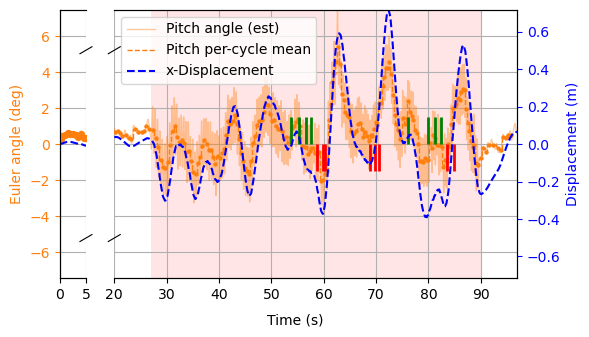

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- color config ----------
pitch_color = 'tab:orange'   # EKF pitch + means (same orange as before)

# ---------- helpers for per-cycle means ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    """
    Compute per-cycle means of y(t) where cycles are defined
    by positive-going zero crossings of a smoothed & detrended
    version of the signal.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), []

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), []

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), []

    tc, means, idxs = [], [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
        idxs.append((i0+1, i1))

    return np.asarray(tc), np.asarray(means), idxs

# ---------- compute per-cycle means for EKF pitch ----------
tc_pitch, m_pitch, _ = per_cycle_means(
    time_s,
    pitch_vo_i,          # <-- EKF pitch
    osc_smooth_s=0.04,
    trend_s=0.6
)

# ---------- broken-axis setup ----------
T_CUT_LOW  = 5.0
T_CUT_HIGH = 20.0

mask_left  = time_s <= T_CUT_LOW
mask_right = time_s >= T_CUT_HIGH

if not (mask_left.any() and mask_right.any()):
    raise ValueError("Cut interval must lie inside the time range.")

t_left_min  = float(time_s[0])
t_left_max  = T_CUT_LOW
t_right_min = T_CUT_HIGH
t_right_max = float(time_s[-1])

span_left  = t_left_max  - t_left_min
span_right = t_right_max - t_right_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 3.5),
    gridspec_kw={'width_ratios': [span_left, span_right]}
)

fig.subplots_adjust(wspace=0.12, bottom=0.18)

# twin axes for NORTH displacement
ax1_r = ax1.twinx()
ax2_r = ax2.twinx()

# ---------- LEFT PANEL ----------
# EKF pitch (background, semi-transparent)
line_pitch, = ax1.plot(
    time_s[mask_left],
    pitch_vo_i[mask_left],
    color=pitch_color,
    alpha=0.4,          # transparency so means stand out
    linewidth=1.0,
    label="Pitch angle (est)",
)

# Per-cycle means (step + dots) on left panel
mask_tc_left = tc_pitch <= T_CUT_LOW
line_mean_left, = ax1.step(
    tc_pitch[mask_tc_left],
    m_pitch[mask_tc_left],
    where='mid',
    color=pitch_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Pitch per-cycle mean"
)
ax1.scatter(
    tc_pitch[mask_tc_left],
    m_pitch[mask_tc_left],
    s=18,
    color=pitch_color,
    marker='o',
    zorder=3
)

# North from Vicon (blue, right twin – axis hidden here)
north_left = north_vic_i[mask_left]
line_north, = ax1_r.plot(
    time_s[mask_left],
    north_left,
    color='b',
    linestyle='--',
    label="North displacement",
)

ax1.set_xlim(t_left_min, t_left_max)
ax1.set_ylabel("Euler angle (deg)")
ax1.grid(True)

# hide right y-axis of left panel’s twin
ax1_r.spines["right"].set_visible(False)
ax1_r.tick_params(right=False, labelright=False)

# ---------- RIGHT PANEL ----------
# EKF pitch (background)
ax2.plot(
    time_s[mask_right],
    pitch_vo_i[mask_right],
    color=pitch_color,
    alpha=0.4,
    linewidth=1.0
)

# Per-cycle means on right panel
mask_tc_right = tc_pitch >= T_CUT_HIGH
ax2.step(
    tc_pitch[mask_tc_right],
    m_pitch[mask_tc_right],
    where='mid',
    color=pitch_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_pitch[mask_tc_right],
    m_pitch[mask_tc_right],
    s=18,
    color=pitch_color,
    marker='.',
    zorder=2
)

# North (blue, dashed) on right twin
north_right = north_vic_i[mask_right]
ax2_r.plot(
    time_s[mask_right],
    north_right,
    color='b',
    linestyle='--'
)

ax2.set_xlim(t_right_min, t_right_max)
ax2.grid(True)
ax2_r.set_ylabel("Displacement (m)")

# ---------- MATCH Y LIMITS (ALIGN ZERO ON BOTH AXES) ----------
# Pitch (left axes): symmetric around 0
pitch_left  = pitch_vo_i[mask_left]
pitch_right = pitch_vo_i[mask_right]
pitch_all = np.concatenate([pitch_left, pitch_right, m_pitch[np.isfinite(m_pitch)]])
pitch_abs = np.nanmax(np.abs(pitch_all))
r_min, r_max = -pitch_abs, pitch_abs
ax1.set_ylim(r_min, r_max)
ax2.set_ylim(r_min, r_max)

# North (right axes): symmetric around 0
north_all = np.concatenate([north_left, north_right])
north_abs = np.nanmax(np.abs(north_all))
e_min, e_max = -north_abs, north_abs
ax1_r.set_ylim(e_min, e_max)
ax2_r.set_ylim(e_min, e_max)

# color axes to match curves
ax1.tick_params(axis='y', colors=pitch_color)
ax1.yaxis.label.set_color(pitch_color)

ax2_r.tick_params(axis='y', colors='b')
ax2_r.yaxis.label.set_color('b')

# Shared x-label
fig.text(0.5, 0.06, "Time (s)", ha="center")

# ---------- CLEAN INNER SPINES / GAP ----------
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax2_r.spines["left"].set_visible(False)

plt.tight_layout(rect=(0, 0.08, 1, 1))

# ---------- BROKEN-AXIS SLASHES ----------
fig.canvas.draw()

bbox1 = ax1.get_window_extent().transformed(fig.transFigure.inverted())
bbox2 = ax2.get_window_extent().transformed(fig.transFigure.inverted())

x1 = bbox1.x1
x2 = bbox2.x0

y_low  = bbox1.y0 + 0.15 * bbox1.height
y_high = bbox1.y1 - 0.15 * bbox1.height

d = 0.010
slash_kwargs = dict(color="k", clip_on=False, linewidth=0.8)

# right edge of left axes
fig.add_artist(Line2D((x1 - d, x1 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x1 - d, x1 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# left edge of right axes
fig.add_artist(Line2D((x2 - d, x2 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x2 - d, x2 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# ---------- RED SHADED BLOCK (t = 27 to 90) ----------
t_shade_start = 27.0
t_shade_end   = 90.0

ax2.axvspan(
    t_shade_start,
    t_shade_end,
    facecolor='red',
    alpha=0.1,
    zorder=0
)

# ---------- VERTICAL POS/NEG MARKERS ----------
marker_times = [53.8, 55.3, 56.6, 57.6,
                58.8, 59.8, 60.3,
                68.9, 69.8, 70.5,
                76.1, 80.0, 81.3, 82.4,
                83.6, 84.9]
marker_signs = [
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG', 'NEG',
    'NEG', 'NEG', 'NEG',
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG'
]

# height = 10% of total pitch range
h_seg = 0.1 * (r_max - r_min)

for t_m, s in zip(marker_times, marker_signs):
    if t_m < T_CUT_HIGH:
        continue
    if s == 'POS':
        y0, y1 = 0.0, h_seg
        color = 'green'
    else:
        y0, y1 = 0.0, -h_seg
        color = 'red'
    ax2.vlines(
        t_m, y0, y1,
        colors=color,
        linewidth=2.0,
        zorder=4
    )

# ---------- LEGEND ----------
ax2.legend(
    [line_pitch, line_mean_left, line_north],
    ["Pitch angle (est)", "Pitch per-cycle mean", "x-Displacement"],
    loc="upper left"
)

plt.show()


In [ ]:
fig.savefig("pitch_est_x.png", dpi=300, bbox_inches='tight') 

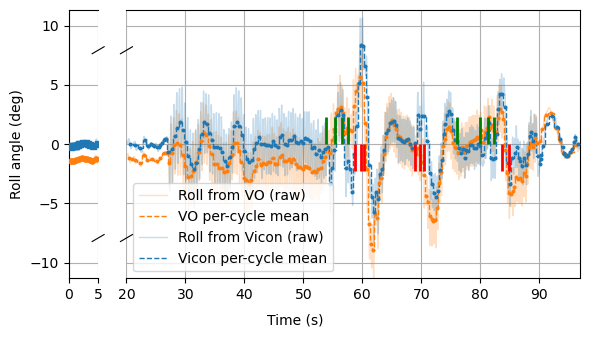

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- color config ----------
vo_color   = 'tab:orange'   # VO EKF roll
vic_color  = 'tab:blue'     # Vicon roll

# ---------- helpers for per-cycle means ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    """
    Compute per-cycle means of y(t) where cycles are defined
    by positive-going zero crossings of a smoothed & detrended
    version of the signal.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), []

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), []

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), []

    tc, means, idxs = [], [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
        idxs.append((i0+1, i1))

    return np.asarray(tc), np.asarray(means), idxs

# ---------- per-cycle means for both roll signals ----------
tc_vo,  m_vo,  _  = per_cycle_means(time_s, roll_vo_i,
                                    osc_smooth_s=0.04, trend_s=0.6)
tc_vic, m_vic, _ = per_cycle_means(time_s, roll_ned_vic_i,
                                   osc_smooth_s=0.04, trend_s=0.6)

# ---------- broken-axis setup ----------
T_CUT_LOW  = 5.0
T_CUT_HIGH = 20.0

mask_left  = time_s <= T_CUT_LOW
mask_right = time_s >= T_CUT_HIGH

if not (mask_left.any() and mask_right.any()):
    raise ValueError("Cut interval must lie inside the time range.")

t_left_min  = float(time_s[0])
t_left_max  = T_CUT_LOW
t_right_min = T_CUT_HIGH
t_right_max = float(time_s[-1])

span_left  = t_left_max  - t_left_min
span_right = t_right_max - t_right_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 3.5),
    gridspec_kw={'width_ratios': [span_left, span_right]}
)

fig.subplots_adjust(wspace=0.12, bottom=0.18)

# ---------- LEFT PANEL ----------
# Raw VO roll (background)
line_vo_raw_left, = ax1.plot(
    time_s[mask_left],
    roll_vo_i[mask_left],
    color=vo_color,
    alpha=0.25,
    linewidth=1.0,
    label="Roll from VO (deg)"
)

# Raw Vicon roll (background)
line_vic_raw_left, = ax1.plot(
    time_s[mask_left],
    roll_ned_vic_i[mask_left],
    color=vic_color,
    alpha=0.25,
    linewidth=1.0,
    label="Roll from Vicon (deg)"
)

# VO per-cycle means
mask_tc_vo_left = tc_vo <= T_CUT_LOW
line_vo_mean_left, = ax1.step(
    tc_vo[mask_tc_vo_left],
    m_vo[mask_tc_vo_left],
    where='mid',
    color=vo_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="VO per-cycle mean"
)
ax1.scatter(
    tc_vo[mask_tc_vo_left],
    m_vo[mask_tc_vo_left],
    s=14,
    color=vo_color,
    marker='o',
    zorder=3
)

# Vicon per-cycle means
mask_tc_vic_left = tc_vic <= T_CUT_LOW
line_vic_mean_left, = ax1.step(
    tc_vic[mask_tc_vic_left],
    m_vic[mask_tc_vic_left],
    where='mid',
    color=vic_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Vicon per-cycle mean"
)
ax1.scatter(
    tc_vic[mask_tc_vic_left],
    m_vic[mask_tc_vic_left],
    s=14,
    color=vic_color,
    marker='s',
    zorder=3
)

ax1.set_xlim(t_left_min, t_left_max)
ax1.set_ylabel("Roll angle (deg)")
ax1.grid(True)

# ---------- RIGHT PANEL ----------
# Raw VO roll
ax2.plot(
    time_s[mask_right],
    roll_vo_i[mask_right],
    color=vo_color,
    alpha=0.25,
    linewidth=1.0
)

# Raw Vicon roll
ax2.plot(
    time_s[mask_right],
    roll_ned_vic_i[mask_right],
    color=vic_color,
    alpha=0.25,
    linewidth=1.0
)

# VO per-cycle means
mask_tc_vo_right = tc_vo >= T_CUT_HIGH
ax2.step(
    tc_vo[mask_tc_vo_right],
    m_vo[mask_tc_vo_right],
    where='mid',
    color=vo_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_vo[mask_tc_vo_right],
    m_vo[mask_tc_vo_right],
    s=14,
    color=vo_color,
    marker='.',
    zorder=3
)

# Vicon per-cycle means
mask_tc_vic_right = tc_vic >= T_CUT_HIGH
ax2.step(
    tc_vic[mask_tc_vic_right],
    m_vic[mask_tc_vic_right],
    where='mid',
    color=vic_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_vic[mask_tc_vic_right],
    m_vic[mask_tc_vic_right],
    s=14,
    color=vic_color,
    marker='.',
    zorder=3
)

ax2.set_xlim(t_right_min, t_right_max)
ax2.grid(True)

# ---------- MATCH Y LIMITS (symmetric about 0) ----------
roll_all = np.concatenate([
    roll_vo_i[mask_left], roll_vo_i[mask_right],
    roll_ned_vic_i[mask_left], roll_ned_vic_i[mask_right],
    m_vo[np.isfinite(m_vo)],
    m_vic[np.isfinite(m_vic)]
])

roll_abs = np.nanmax(np.abs(roll_all))
r_min, r_max = -roll_abs, roll_abs
ax1.set_ylim(r_min, r_max)
ax2.set_ylim(r_min, r_max)

# Shared x-label
fig.text(0.5, 0.06, "Time (s)", ha="center")

# ---------- CLEAN INNER SPINES / GAP ----------
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))

# ---------- BROKEN-AXIS SLASHES ----------
fig.canvas.draw()

bbox1 = ax1.get_window_extent().transformed(fig.transFigure.inverted())
bbox2 = ax2.get_window_extent().transformed(fig.transFigure.inverted())

x1 = bbox1.x1
x2 = bbox2.x0

y_low  = bbox1.y0 + 0.15 * bbox1.height
y_high = bbox1.y1 - 0.15 * bbox1.height

d = 0.010
slash_kwargs = dict(color="k", clip_on=False, linewidth=0.8)

# right edge of left axes
fig.add_artist(Line2D((x1 - d, x1 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x1 - d, x1 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# left edge of right axes
fig.add_artist(Line2D((x2 - d, x2 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x2 - d, x2 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# ---------- RED SHADED BLOCK (t = 27 to 90) ----------
# t_shade_start = 27.0
# t_shade_end   = 90.0
# ax2.axvspan(
#     t_shade_start,
#     t_shade_end,
#     facecolor='red',
#     alpha=0.1,
#     zorder=0
# )

# ---------- VERTICAL POS/NEG MARKERS ----------
marker_times = [53.8, 55.3, 56.6, 57.6,
                58.8, 59.8, 60.3,
                68.9, 69.8, 70.5,
                76.1, 80.0, 81.3, 82.4,
                83.6, 84.9]
marker_signs = [
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG', 'NEG',
    'NEG', 'NEG', 'NEG',
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG'
]

h_seg = 0.1 * (r_max - r_min)  # 10% of roll range

for t_m, s in zip(marker_times, marker_signs):
    if t_m < T_CUT_HIGH:
        continue  # markers only on right panel
    if s == 'POS':
        y0, y1 = 0.0, h_seg
        color = 'green'
    else:
        y0, y1 = 0.0, -h_seg
        color = 'red'
    ax2.vlines(
        t_m, y0, y1,
        colors=color,
        linewidth=2.0,
        zorder=4
    )

# ---------- LEGEND ----------
ax2.legend(
    [line_vo_raw_left, line_vo_mean_left,
     line_vic_raw_left, line_vic_mean_left],
    ["Roll from VO (raw)", "VO per-cycle mean",
     "Roll from Vicon (raw)", "Vicon per-cycle mean"],
    loc="lower left"
)

plt.show()


In [48]:
fig.savefig("roll_vicon_vo.png", dpi=300, bbox_inches='tight') 

In [49]:
import numpy as np

# --------- choose interval for stats ----------
# Full time range:
mask_all = np.isfinite(time_s) & np.isfinite(roll_vo_i) & np.isfinite(roll_ned_vic_i)

# Attack window (same as shaded region in the plot)
t_shade_start = 27.0
t_shade_end   = 90.0
mask_attack = (
    (time_s >= t_shade_start) &
    (time_s <= t_shade_end) &
    np.isfinite(roll_vo_i) &
    np.isfinite(roll_ned_vic_i)
)

# Helper to print stats for any series
def print_stats(name, y, mask):
    y_sel = y[mask]
    mean = np.nanmean(y_sel)
    std  = np.nanstd(y_sel)
    print(f"{name}: mean = {mean:.3f} deg, std = {std:.3f} deg, N = {y_sel.size}")

# --------- 1) Overall stats over entire run ----------
print("=== FULL RUN STATS ===")
print_stats("VO roll",    roll_vo_i,       mask_all)
print_stats("Vicon roll", roll_ned_vic_i,  mask_all)

diff_all = roll_vo_i - roll_ned_vic_i
print_stats("VO - Vicon (error)", diff_all, mask_all)

# --------- 2) Stats in the ATTACK WINDOW only ----------
print("\n=== ATTACK WINDOW STATS (t in [27, 90] s) ===")
print_stats("VO roll",    roll_vo_i,       mask_attack)
print_stats("Vicon roll", roll_ned_vic_i,  mask_attack)

diff_attack = roll_vo_i - roll_ned_vic_i
print_stats("VO - Vicon (error)", diff_attack, mask_attack)

# --------- 3) (Optional) stats of PER-CYCLE MEANS ----------
# Only run this part if you already computed:
#   tc_vo,  m_vo  = per-cycle means for roll_vo_i
#   tc_vic, m_vic = per-cycle means for roll_ned_vic_i

if "tc_vo" in globals() and "m_vo" in globals():
    # mask per-cycle centers by attack window
    mask_tc_vo_all     = np.isfinite(m_vo)
    mask_tc_vo_attack  = mask_tc_vo_all & (tc_vo >= t_shade_start) & (tc_vo <= t_shade_end)

    print("\n=== VO PER-CYCLE MEANS ===")
    print_stats("VO per-cycle mean (full)",  m_vo, mask_tc_vo_all)
    print_stats("VO per-cycle mean (attack)", m_vo, mask_tc_vo_attack)

if "tc_vic" in globals() and "m_vic" in globals():
    mask_tc_vic_all    = np.isfinite(m_vic)
    mask_tc_vic_attack = mask_tc_vic_all & (tc_vic >= t_shade_start) & (tc_vic <= t_shade_end)

    print("\n=== VICON PER-CYCLE MEANS ===")
    print_stats("Vicon per-cycle mean (full)",  m_vic, mask_tc_vic_all)
    print_stats("Vicon per-cycle mean (attack)", m_vic, mask_tc_vic_attack)


=== FULL RUN STATS ===
VO roll: mean = -0.890 deg, std = 2.344 deg, N = 9689
Vicon roll: mean = 0.054 deg, std = 2.081 deg, N = 9689
VO - Vicon (error): mean = -0.945 deg, std = 2.001 deg, N = 9689

=== ATTACK WINDOW STATS (t in [27, 90] s) ===
VO roll: mean = -0.909 deg, std = 2.812 deg, N = 6300
Vicon roll: mean = 0.039 deg, std = 2.539 deg, N = 6300
VO - Vicon (error): mean = -0.948 deg, std = 2.431 deg, N = 6300

=== VO PER-CYCLE MEANS ===
VO per-cycle mean (full): mean = -0.901 deg, std = 2.095 deg, N = 227
VO per-cycle mean (attack): mean = -0.896 deg, std = 2.353 deg, N = 172

=== VICON PER-CYCLE MEANS ===
Vicon per-cycle mean (full): mean = 0.003 deg, std = 1.693 deg, N = 247
Vicon per-cycle mean (attack): mean = 0.026 deg, std = 2.031 deg, N = 166


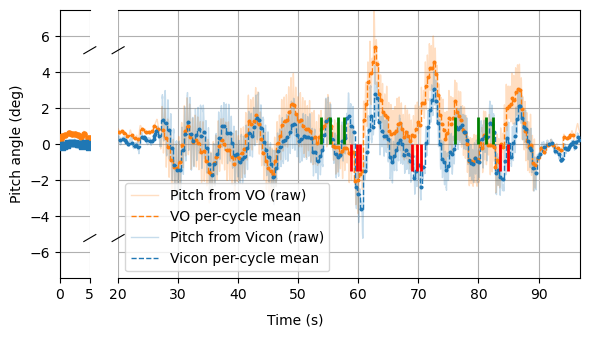

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- color config ----------
vo_color  = 'tab:orange'   # VO EKF pitch
vic_color = 'tab:blue'     # Vicon pitch

# ---------- helpers for per-cycle means ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    """
    Compute per-cycle means of y(t) where cycles are defined
    by positive-going zero crossings of a smoothed & detrended
    version of the signal.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), []

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), []

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), []

    tc, means, idxs = [], [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
        idxs.append((i0+1, i1))

    return np.asarray(tc), np.asarray(means), idxs

# ---------- per-cycle means for VO/Vicon pitch ----------
tc_vo,  m_vo,  _  = per_cycle_means(time_s, pitch_vo_i,
                                    osc_smooth_s=0.04, trend_s=0.6)
tc_vic, m_vic, _ = per_cycle_means(time_s, pitch_vic_i,
                                   osc_smooth_s=0.04, trend_s=0.6)

# ---------- broken-axis setup ----------
T_CUT_LOW  = 5.0
T_CUT_HIGH = 20.0

mask_left  = time_s <= T_CUT_LOW
mask_right = time_s >= T_CUT_HIGH

if not (mask_left.any() and mask_right.any()):
    raise ValueError("Cut interval must lie inside the time range.")

t_left_min  = float(time_s[0])
t_left_max  = T_CUT_LOW
t_right_min = T_CUT_HIGH
t_right_max = float(time_s[-1])

span_left  = t_left_max  - t_left_min
span_right = t_right_max - t_right_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 3.5),
    gridspec_kw={'width_ratios': [span_left, span_right]}
)

fig.subplots_adjust(wspace=0.12, bottom=0.18)

# ---------- LEFT PANEL ----------
# Raw VO pitch (background)
line_vo_raw_left, = ax1.plot(
    time_s[mask_left],
    pitch_vo_i[mask_left],
    color=vo_color,
    alpha=0.25,
    linewidth=1.0,
    label="Pitch from VO (deg)"
)

# Raw Vicon pitch (background)
line_vic_raw_left, = ax1.plot(
    time_s[mask_left],
    pitch_vic_i[mask_left],
    color=vic_color,
    alpha=0.25,
    linewidth=1.0,
    label="Pitch from Vicon (deg)"
)

# VO per-cycle means (step + dots)
mask_tc_vo_left = tc_vo <= T_CUT_LOW
line_vo_mean_left, = ax1.step(
    tc_vo[mask_tc_vo_left],
    m_vo[mask_tc_vo_left],
    where='mid',
    color=vo_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="VO per-cycle mean"
)
ax1.scatter(
    tc_vo[mask_tc_vo_left],
    m_vo[mask_tc_vo_left],
    s=14,
    color=vo_color,
    marker='o',
    zorder=3
)

# Vicon per-cycle means
mask_tc_vic_left = tc_vic <= T_CUT_LOW
line_vic_mean_left, = ax1.step(
    tc_vic[mask_tc_vic_left],
    m_vic[mask_tc_vic_left],
    where='mid',
    color=vic_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Vicon per-cycle mean"
)
ax1.scatter(
    tc_vic[mask_tc_vic_left],
    m_vic[mask_tc_vic_left],
    s=14,
    color=vic_color,
    marker='s',
    zorder=3
)

ax1.set_xlim(t_left_min, t_left_max)
ax1.set_ylabel("Pitch angle (deg)")
ax1.grid(True)

# ---------- RIGHT PANEL ----------
# Raw VO pitch
ax2.plot(
    time_s[mask_right],
    pitch_vo_i[mask_right],
    color=vo_color,
    alpha=0.25,
    linewidth=1.0
)

# Raw Vicon pitch
ax2.plot(
    time_s[mask_right],
    pitch_vic_i[mask_right],
    color=vic_color,
    alpha=0.25,
    linewidth=1.0
)

# VO per-cycle means
mask_tc_vo_right = tc_vo >= T_CUT_HIGH
ax2.step(
    tc_vo[mask_tc_vo_right],
    m_vo[mask_tc_vo_right],
    where='mid',
    color=vo_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_vo[mask_tc_vo_right],
    m_vo[mask_tc_vo_right],
    s=14,
    color=vo_color,
    marker='.',
    zorder=3
)

# Vicon per-cycle means
mask_tc_vic_right = tc_vic >= T_CUT_HIGH
ax2.step(
    tc_vic[mask_tc_vic_right],
    m_vic[mask_tc_vic_right],
    where='mid',
    color=vic_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_vic[mask_tc_vic_right],
    m_vic[mask_tc_vic_right],
    s=14,
    color=vic_color,
    marker='.',
    zorder=3
)

ax2.set_xlim(t_right_min, t_right_max)
ax2.grid(True)

# ---------- MATCH Y LIMITS (symmetric about 0) ----------
pitch_all = np.concatenate([
    pitch_vo_i[mask_left], pitch_vo_i[mask_right],
    pitch_vic_i[mask_left], pitch_vic_i[mask_right],
    m_vo[np.isfinite(m_vo)],
    m_vic[np.isfinite(m_vic)]
])

pitch_abs = np.nanmax(np.abs(pitch_all))
y_min, y_max = -pitch_abs, pitch_abs
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Shared x-label
fig.text(0.5, 0.06, "Time (s)", ha="center")

# ---------- CLEAN INNER SPINES / GAP ----------
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))

# ---------- BROKEN-AXIS SLASHES ----------
fig.canvas.draw()

bbox1 = ax1.get_window_extent().transformed(fig.transFigure.inverted())
bbox2 = ax2.get_window_extent().transformed(fig.transFigure.inverted())

x1 = bbox1.x1
x2 = bbox2.x0

y_low  = bbox1.y0 + 0.15 * bbox1.height
y_high = bbox1.y1 - 0.15 * bbox1.height

d = 0.010
slash_kwargs = dict(color="k", clip_on=False, linewidth=0.8)

# right edge of left axes
fig.add_artist(Line2D((x1 - d, x1 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x1 - d, x1 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# left edge of right axes
fig.add_artist(Line2D((x2 - d, x2 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x2 - d, x2 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# ---------- RED SHADED BLOCK (t = 27 to 90) ----------
# t_shade_start = 27.0
# t_shade_end   = 90.0
# ax2.axvspan(
#     t_shade_start,
#     t_shade_end,
#     facecolor='red',
#     alpha=0.1,
#     zorder=0
# )

# ---------- VERTICAL POS/NEG MARKERS ----------
marker_times = [53.8, 55.3, 56.6, 57.6,
                58.8, 59.8, 60.3,
                68.9, 69.8, 70.5,
                76.1, 80.0, 81.3, 82.4,
                83.6, 84.9]
marker_signs = [
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG', 'NEG',
    'NEG', 'NEG', 'NEG',
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG'
]

h_seg = 0.1 * (y_max - y_min)  # 10% of pitch range

for t_m, s in zip(marker_times, marker_signs):
    if t_m < T_CUT_HIGH:
        continue  # markers only on right panel
    if s == 'POS':
        y0, y1 = 0.0, h_seg
        color = 'green'
    else:
        y0, y1 = 0.0, -h_seg
        color = 'red'
    ax2.vlines(
        t_m, y0, y1,
        colors=color,
        linewidth=2.0,
        zorder=4
    )

# ---------- LEGEND ----------
ax2.legend(
    [line_vo_raw_left, line_vo_mean_left,
     line_vic_raw_left, line_vic_mean_left],
    ["Pitch from VO (raw)", "VO per-cycle mean",
     "Pitch from Vicon (raw)", "Vicon per-cycle mean"],
    loc="lower left"
)

plt.show()


In [53]:
fig.savefig("pitch_vicon_vo.png", dpi=300, bbox_inches='tight') 

In [54]:
import numpy as np

# ----- define the time window of interest (same as shaded block) -----
t_shade_start = 27.0
t_shade_end   = 90.0

# mask for raw pitch signals in this window
mask_win = (time_s >= t_shade_start) & (time_s <= t_shade_end)

pitch_vo_win  = pitch_vo_i[mask_win]
pitch_vic_win = pitch_vic_i[mask_win]

# ---------- raw-signal stats ----------
vo_raw_mean  = np.nanmean(pitch_vo_win)
vo_raw_std   = np.nanstd(pitch_vo_win, ddof=1)

vic_raw_mean = np.nanmean(pitch_vic_win)
vic_raw_std  = np.nanstd(pitch_vic_win, ddof=1)

print("RAW PITCH (attack window [{:.1f}, {:.1f}] s)".format(t_shade_start, t_shade_end))
print("  VO   : mean = {:.3f} deg, std = {:.3f} deg".format(vo_raw_mean,  vo_raw_std))
print("  Vicon: mean = {:.3f} deg, std = {:.3f} deg".format(vic_raw_mean, vic_raw_std))

# ---------- per-cycle means stats ----------
# Use the per-cycle centers that fall inside the same window
mask_tc_vo   = (tc_vo  >= t_shade_start) & (tc_vo  <= t_shade_end)
mask_tc_vic  = (tc_vic >= t_shade_start) & (tc_vic <= t_shade_end)

vo_cycle_means   = m_vo[mask_tc_vo]
vic_cycle_means  = m_vic[mask_tc_vic]

vo_cycle_mean    = np.nanmean(vo_cycle_means)
vo_cycle_std     = np.nanstd(vo_cycle_means, ddof=1) if vo_cycle_means.size > 1 else np.nan

vic_cycle_mean   = np.nanmean(vic_cycle_means)
vic_cycle_std    = np.nanstd(vic_cycle_means, ddof=1) if vic_cycle_means.size > 1 else np.nan

print("\nPER-CYCLE MEANS (attack window [{:.1f}, {:.1f}] s)".format(t_shade_start, t_shade_end))
print("  VO   : mean = {:.3f} deg, std = {:.3f} deg".format(vo_cycle_mean,  vo_cycle_std))
print("  Vicon: mean = {:.3f} deg, std = {:.3f} deg".format(vic_cycle_mean, vic_cycle_std))


RAW PITCH (attack window [27.0, 90.0] s)
  VO   : mean = 0.588 deg, std = 1.730 deg
  Vicon: mean = -0.007 deg, std = 1.393 deg

PER-CYCLE MEANS (attack window [27.0, 90.0] s)
  VO   : mean = 0.649 deg, std = 1.444 deg
  Vicon: mean = 0.022 deg, std = 1.106 deg


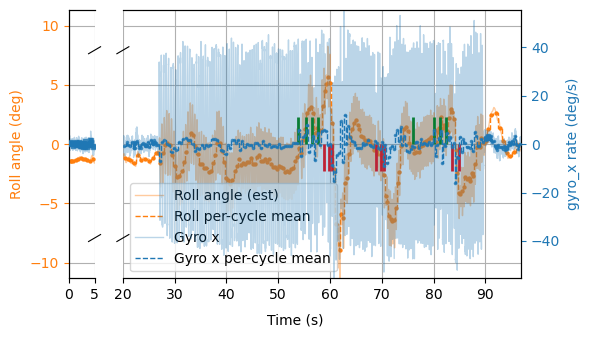

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- color config ----------
roll_color = 'tab:orange'   # EKF roll + means
rate_color = 'tab:blue'     # gyro rate + means

# ---------- helpers for per-cycle means ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), []

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), []

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), []

    tc, means, idxs = [], [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
        idxs.append((i0+1, i1))

    return np.asarray(tc), np.asarray(means), idxs

# ---------- per-cycle means ----------
tc_roll, m_roll, _ = per_cycle_means(
    time_s,
    roll_vo_i,
    osc_smooth_s=0.04,
    trend_s=0.6
)

tc_rate, m_rate, _ = per_cycle_means(
    time_s,
    p_deg_s,
    osc_smooth_s=0.04,
    trend_s=0.6
)

# ---------- broken-axis setup ----------
T_CUT_LOW  = 5.0
T_CUT_HIGH = 20.0

mask_left  = time_s <= T_CUT_LOW
mask_right = time_s >= T_CUT_HIGH

if not (mask_left.any() and mask_right.any()):
    raise ValueError("Cut interval must lie inside the time range.")

t_left_min  = float(time_s[0])
t_left_max  = T_CUT_LOW
t_right_min = T_CUT_HIGH
t_right_max = float(time_s[-1])

span_left  = t_left_max  - t_left_min
span_right = t_right_max - t_right_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 3.5),
    gridspec_kw={'width_ratios': [span_left, span_right]}
)

fig.subplots_adjust(wspace=0.12, bottom=0.18)

# twin axes for gyro rate
ax1_r = ax1.twinx()
ax2_r = ax2.twinx()

# ---------- LEFT PANEL ----------
line_roll, = ax1.plot(
    time_s[mask_left],
    roll_vo_i[mask_left],
    color=roll_color,
    alpha=0.4,
    linewidth=1.0,
    label="Roll angle (est)"
)

mask_tc_left_roll = tc_roll <= T_CUT_LOW
line_mean_left, = ax1.step(
    tc_roll[mask_tc_left_roll],
    m_roll[mask_tc_left_roll],
    where='mid',
    color=roll_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Roll per-cycle mean"
)
ax1.scatter(
    tc_roll[mask_tc_left_roll],
    m_roll[mask_tc_left_roll],
    s=18,
    color=roll_color,
    marker='.',
    zorder=3
)

rate_left = p_deg_s[mask_left]
line_rate_left, = ax1_r.plot(
    time_s[mask_left],
    rate_left,
    color=rate_color,
    alpha=0.3,
    linewidth=1.0,
    label="gyro_x → p (deg/s)"
)

mask_tc_left_rate = tc_rate <= T_CUT_LOW
line_rate_mean_left, = ax1_r.step(
    tc_rate[mask_tc_left_rate],
    m_rate[mask_tc_left_rate],
    where='mid',
    color=rate_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Rate per-cycle mean"
)
# smaller, lighter markers for rate means
ax1_r.scatter(
    tc_rate[mask_tc_left_rate],
    m_rate[mask_tc_left_rate],
    s=10,              # <-- smaller
    color=rate_color,
    marker='s',
    alpha=0.7,         # <-- slightly transparent
    zorder=3
)

ax1.set_xlim(t_left_min, t_left_max)
ax1.set_ylabel("Roll angle (deg)")
ax1.grid(True)

ax1_r.spines["right"].set_visible(False)
ax1_r.tick_params(right=False, labelright=False)

# ---------- RIGHT PANEL ----------
ax2.plot(
    time_s[mask_right],
    roll_vo_i[mask_right],
    color=roll_color,
    alpha=0.4,
    linewidth=1.0
)

mask_tc_right_roll = tc_roll >= T_CUT_HIGH
ax2.step(
    tc_roll[mask_tc_right_roll],
    m_roll[mask_tc_right_roll],
    where='mid',
    color=roll_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_roll[mask_tc_right_roll],
    m_roll[mask_tc_right_roll],
    s=18,
    color=roll_color,
    marker='.',
    zorder=3
)

rate_right = p_deg_s[mask_right]
ax2_r.plot(
    time_s[mask_right],
    rate_right,
    color=rate_color,
    alpha=0.3,
    linewidth=1.0
)

mask_tc_right_rate = tc_rate >= T_CUT_HIGH
ax2_r.step(
    tc_rate[mask_tc_right_rate],
    m_rate[mask_tc_right_rate],
    where='mid',
    color=rate_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2_r.scatter(
    tc_rate[mask_tc_right_rate],
    m_rate[mask_tc_right_rate],
    s=10,              # <-- smaller
    color=rate_color,
    marker='.',
    alpha=0.7,         # <-- slightly transparent
    zorder=3
)

ax2.set_xlim(t_right_min, t_right_max)
ax2.grid(True)
ax2_r.set_ylabel("gyro_x rate (deg/s)")

# ---------- MATCH Y LIMITS ----------
roll_left  = roll_vo_i[mask_left]
roll_right = roll_vo_i[mask_right]
roll_all = np.concatenate([roll_left, roll_right, m_roll[np.isfinite(m_roll)]])
roll_abs = np.nanmax(np.abs(roll_all))
r_min, r_max = -roll_abs, roll_abs
ax1.set_ylim(r_min, r_max)
ax2.set_ylim(r_min, r_max)

rate_all = np.concatenate([rate_left, rate_right, m_rate[np.isfinite(m_rate)]])
rate_abs = np.nanmax(np.abs(rate_all))
e_min, e_max = -rate_abs, rate_abs
ax1_r.set_ylim(e_min, e_max)
ax2_r.set_ylim(e_min, e_max)

ax1.tick_params(axis='y', colors=roll_color)
ax1.yaxis.label.set_color(roll_color)

ax2_r.tick_params(axis='y', colors=rate_color)
ax2_r.yaxis.label.set_color(rate_color)

fig.text(0.5, 0.06, "Time (s)", ha="center")

ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax2_r.spines["left"].set_visible(False)

plt.tight_layout(rect=(0, 0.08, 1, 1))

fig.canvas.draw()

bbox1 = ax1.get_window_extent().transformed(fig.transFigure.inverted())
bbox2 = ax2.get_window_extent().transformed(fig.transFigure.inverted())

x1 = bbox1.x1
x2 = bbox2.x0

y_low  = bbox1.y0 + 0.15 * bbox1.height
y_high = bbox1.y1 - 0.15 * bbox1.height

d = 0.010
slash_kwargs = dict(color="k", clip_on=False, linewidth=0.8)

fig.add_artist(Line2D((x1 - d, x1 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x1 - d, x1 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

fig.add_artist(Line2D((x2 - d, x2 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x2 - d, x2 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

marker_times = [53.8, 55.3, 56.6, 57.6,
                58.8, 59.8, 60.3,
                68.9, 69.8, 70.5,
                76.1, 80.0, 81.3, 82.4,
                83.6, 84.9]
marker_signs = [
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG', 'NEG',
    'NEG', 'NEG', 'NEG',
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG'
]

h_seg = 0.1 * (r_max - r_min)

for t_m, s in zip(marker_times, marker_signs):
    if t_m < T_CUT_HIGH:
        continue
    if s == 'POS':
        y0, y1 = 0.0, h_seg
        color = 'green'
    else:
        y0, y1 = 0.0, -h_seg
        color = 'red'
    ax2.vlines(
        t_m, y0, y1,
        colors=color,
        linewidth=2.0,
        zorder=4
    )

ax2.legend(
    [line_roll, line_mean_left, line_rate_left, line_rate_mean_left],
    ["Roll angle (est)", "Roll per-cycle mean",
     "Gyro x", "Gyro x per-cycle mean"],
    loc="lower left"
)

plt.show()


In [ ]:
fig.savefig("gyro_roll_est.png", dpi=300, bbox_inches='tight') 

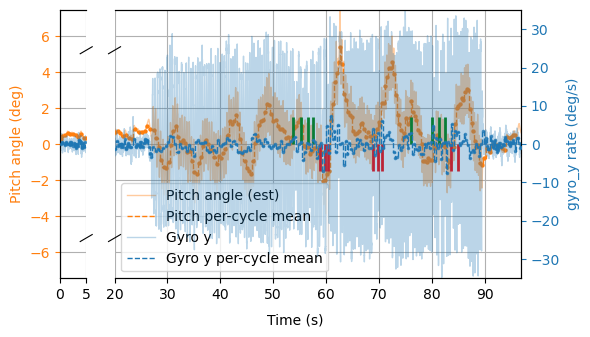

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- color config ----------
pitch_color = 'tab:orange'   # EKF pitch + means
rate_color  = 'tab:blue'     # gyro y rate + means

# ---------- helpers for per-cycle means ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    """
    Compute per-cycle means of y(t) where cycles are defined
    by positive-going zero crossings of a smoothed & detrended
    version of the signal.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), []

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), []

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), []

    tc, means, idxs = [], [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
        idxs.append((i0+1, i1))

    return np.asarray(tc), np.asarray(means), idxs

# ---------- per-cycle means ----------
# Pitch from VO EKF
tc_pitch, m_pitch, _ = per_cycle_means(
    time_s,
    pitch_vo_i,
    osc_smooth_s=0.04,
    trend_s=0.6
)

# Gyro y rate (deg/s)
tc_rate, m_rate, _ = per_cycle_means(
    time_s,
    q_deg_s,          # <--- gyro_y → q in deg/s
    osc_smooth_s=0.04,
    trend_s=0.6
)

# ---------- broken-axis setup ----------
T_CUT_LOW  = 5.0
T_CUT_HIGH = 20.0

mask_left  = time_s <= T_CUT_LOW
mask_right = time_s >= T_CUT_HIGH

if not (mask_left.any() and mask_right.any()):
    raise ValueError("Cut interval must lie inside the time range.")

t_left_min  = float(time_s[0])
t_left_max  = T_CUT_LOW
t_right_min = T_CUT_HIGH
t_right_max = float(time_s[-1])

span_left  = t_left_max  - t_left_min
span_right = t_right_max - t_right_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 3.5),
    gridspec_kw={'width_ratios': [span_left, span_right]}
)

fig.subplots_adjust(wspace=0.12, bottom=0.18)

# twin axes for gyro rate
ax1_r = ax1.twinx()
ax2_r = ax2.twinx()

# ---------- LEFT PANEL ----------
# Pitch (background, semi-transparent)
line_pitch, = ax1.plot(
    time_s[mask_left],
    pitch_vo_i[mask_left],
    color=pitch_color,
    alpha=0.4,
    linewidth=1.0,
    label="Pitch angle (est)"
)

# Pitch per-cycle means (step + dots)
mask_tc_left_pitch = tc_pitch <= T_CUT_LOW
line_mean_left, = ax1.step(
    tc_pitch[mask_tc_left_pitch],
    m_pitch[mask_tc_left_pitch],
    where='mid',
    color=pitch_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Pitch per-cycle mean"
)
ax1.scatter(
    tc_pitch[mask_tc_left_pitch],
    m_pitch[mask_tc_left_pitch],
    s=18,
    color=pitch_color,
    marker='.',
    zorder=3
)

# Gyro y rate on right twin (background)
rate_left = q_deg_s[mask_left]
line_rate_left, = ax1_r.plot(
    time_s[mask_left],
    rate_left,
    color=rate_color,
    alpha=0.3,
    linewidth=1.0,
    label="gyro_y → q (deg/s)"
)

# Gyro y rate per-cycle mean
mask_tc_left_rate = tc_rate <= T_CUT_LOW
line_rate_mean_left, = ax1_r.step(
    tc_rate[mask_tc_left_rate],
    m_rate[mask_tc_left_rate],
    where='mid',
    color=rate_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0,
    label="Rate per-cycle mean"
)
ax1_r.scatter(
    tc_rate[mask_tc_left_rate],
    m_rate[mask_tc_left_rate],
    s=10,
    color=rate_color,
    marker='.',
    alpha=0.7,
    zorder=3
)

ax1.set_xlim(t_left_min, t_left_max)
ax1.set_ylabel("Pitch angle (deg)")
ax1.grid(True)

ax1_r.spines["right"].set_visible(False)
ax1_r.tick_params(right=False, labelright=False)

# ---------- RIGHT PANEL ----------
ax2.plot(
    time_s[mask_right],
    pitch_vo_i[mask_right],
    color=pitch_color,
    alpha=0.4,
    linewidth=1.0
)

mask_tc_right_pitch = tc_pitch >= T_CUT_HIGH
ax2.step(
    tc_pitch[mask_tc_right_pitch],
    m_pitch[mask_tc_right_pitch],
    where='mid',
    color=pitch_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2.scatter(
    tc_pitch[mask_tc_right_pitch],
    m_pitch[mask_tc_right_pitch],
    s=18,
    color=pitch_color,
    marker='.',
    zorder=2
)

rate_right = q_deg_s[mask_right]
ax2_r.plot(
    time_s[mask_right],
    rate_right,
    color=rate_color,
    alpha=0.3,
    linewidth=1.0
)

mask_tc_right_rate = tc_rate >= T_CUT_HIGH
ax2_r.step(
    tc_rate[mask_tc_right_rate],
    m_rate[mask_tc_right_rate],
    where='mid',
    color=rate_color,
    linestyle='--',
    linewidth=1.0,
    alpha=1.0
)
ax2_r.scatter(
    tc_rate[mask_tc_right_rate],
    m_rate[mask_tc_right_rate],
    s=10,
    color=rate_color,
    marker='.',
    alpha=0.7,
    zorder=3
)

ax2.set_xlim(t_right_min, t_right_max)
ax2.grid(True)
ax2_r.set_ylabel("gyro_y rate (deg/s)")

# ---------- MATCH Y LIMITS ----------
# Pitch (left axes)
pitch_left  = pitch_vo_i[mask_left]
pitch_right = pitch_vo_i[mask_right]
pitch_all = np.concatenate([pitch_left, pitch_right, m_pitch[np.isfinite(m_pitch)]])
pitch_abs = np.nanmax(np.abs(pitch_all))
r_min, r_max = -pitch_abs, pitch_abs
ax1.set_ylim(r_min, r_max)
ax2.set_ylim(r_min, r_max)

# Rate (right axes)
rate_all = np.concatenate([rate_left, rate_right, m_rate[np.isfinite(m_rate)]])
rate_abs = np.nanmax(np.abs(rate_all))
e_min, e_max = -rate_abs, rate_abs
ax1_r.set_ylim(e_min, e_max)
ax2_r.set_ylim(e_min, e_max)

ax1.tick_params(axis='y', colors=pitch_color)
ax1.yaxis.label.set_color(pitch_color)

ax2_r.tick_params(axis='y', colors=rate_color)
ax2_r.yaxis.label.set_color(rate_color)

fig.text(0.5, 0.06, "Time (s)", ha="center")

ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax2_r.spines["left"].set_visible(False)

plt.tight_layout(rect=(0, 0.08, 1, 1))

fig.canvas.draw()

bbox1 = ax1.get_window_extent().transformed(fig.transFigure.inverted())
bbox2 = ax2.get_window_extent().transformed(fig.transFigure.inverted())

x1 = bbox1.x1
x2 = bbox2.x0

y_low  = bbox1.y0 + 0.15 * bbox1.height
y_high = bbox1.y1 - 0.15 * bbox1.height

d = 0.010
slash_kwargs = dict(color="k", clip_on=False, linewidth=0.8)

fig.add_artist(Line2D((x1 - d, x1 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x1 - d, x1 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

fig.add_artist(Line2D((x2 - d, x2 + d), (y_low  - d, y_low  + d),
                      transform=fig.transFigure, **slash_kwargs))
fig.add_artist(Line2D((x2 - d, x2 + d), (y_high - d, y_high + d),
                      transform=fig.transFigure, **slash_kwargs))

# vertical marker positions + signs (reuse if you like)
marker_times = [53.8, 55.3, 56.6, 57.6,
                58.8, 59.8, 60.3,
                68.9, 69.8, 70.5,
                76.1, 80.0, 81.3, 82.4,
                83.6, 84.9]
marker_signs = [
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG', 'NEG',
    'NEG', 'NEG', 'NEG',
    'POS', 'POS', 'POS', 'POS',
    'NEG', 'NEG'
]

h_seg = 0.1 * (r_max - r_min)

for t_m, s in zip(marker_times, marker_signs):
    if t_m < T_CUT_HIGH:
        continue
    if s == 'POS':
        y0, y1 = 0.0, h_seg
        color = 'green'
    else:
        y0, y1 = 0.0, -h_seg
        color = 'red'
    ax2.vlines(
        t_m, y0, y1,
        colors=color,
        linewidth=2.0,
        zorder=4
    )

ax2.legend(
    [line_pitch, line_mean_left, line_rate_left, line_rate_mean_left],
    ["Pitch angle (est)", "Pitch per-cycle mean",
     "Gyro y", "Gyro y per-cycle mean"],
    loc="lower left"
)

plt.show()


In [ ]:
fig.savefig("gyro_pitch_est.png", dpi=300, bbox_inches='tight') 